# Dividend Initiation and Omission — Descriptive Statistics

Descriptive-statistics chapter of the MSc thesis. All characteristics are same-year (current fiscal year) values recovered from the full engineered panel. The ML risk-set CSVs supply sample membership and targets only.

**Thesis outputs:** Figure 3.1, Tables 5.1–5.2, and appendix tables for annual counts and full summary statistics.

## Section 1 — Setup

Libraries, path constants, colour palette, theory-block mapping, and crisis-period definitions. Paths are relative to the `Submission` folder so this notebook runs independently of external workspaces.

In [5]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

warnings.filterwarnings('ignore')

PROJECT_DIR = Path.cwd()
DATA_DIR    = PROJECT_DIR / 'data'
INIT_PATH   = DATA_DIR / 'ml_dividend_initiations_1990_2025.csv'
OMIT_PATH   = DATA_DIR / 'ml_dividend_omissions_1990_2025.csv'
FULL_PATH   = DATA_DIR / 'dividend_full_engineered_panel_1963_2025.csv'
FEAT_PATH   = DATA_DIR / 'ml_feature_list.csv'

RESULTS_DIR = PROJECT_DIR / 'results'
TABLES_DIR  = RESULTS_DIR / 'tables/'
FIGURES_DIR = RESULTS_DIR / 'figures/'
for d in (TABLES_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

UU_GREEN  = '#007A33'
UU_RED    = '#C00A35'
UU_BLUE   = '#002B7F'
UU_PURPLE = '#6E1F7C'
UU_DKBLUE = '#001240'
UU_GRAY   = '#767676'
UU_YELLOW = '#F0AB00'

CRISES = [
    ('Dot-com',    2000, 2002, UU_RED,    0.12),
    ('GFC',        2007, 2009, UU_DKBLUE, 0.12),
    ('COVID',      2020, 2020, UU_PURPLE, 0.12),
    ('Rate Shock', 2022, 2022, UU_YELLOW, 0.12),
]

THEORY_BLOCKS = {
    '1. Life-Cycle & Maturity': [
        'RE_TE', 'RE_TA', 'TE_TA', 'Size', 'Log_MarketCap',
        'Sales_Growth', 'Asset_Growth', 'Listing_Age'
    ],
    '2. Growth Options & Investment': [
        'Market_to_Book', 'CapEx_to_Assets', 'RD_assets', 'Price_to_Sales'
    ],
    '3. Signaling & Profitability': [
        'ROA', 'ROE', 'OpCF_to_Assets', 'ORA', 'Profit_Margin', 'Accruals'
    ],
    '4. Free Cash Flow & Agency': [
        'Cash_to_Assets', 'FCF_to_Assets', 'Repurchase_to_Assets', 'Goodwill_to_Assets'
    ],
    '5. Conservatism & Risk': [
        'Leverage', 'LTDA', 'Current_Ratio', 'Earnings_Volatility',
        'Interest_Coverage', 'FAT', 'LCTAT', 'Labor_Intensity'
    ],
    '6. Corporate Taxation': ['GAAP_ETR', 'Cash_ETR'],
    '7. Transaction Cost Theory': ['Share_Turnover'],
    '8. Catering Premium (Behavioral)': ['DIVPREM'],
}
ALL_FEATURES = [v for block in THEORY_BLOCKS.values() for v in block]   # 34 vars

# Market-wide scalar — no appendix event/non-event split
MARKET_WIDE = {'DIVPREM'}

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 180)
plt.style.use('seaborn-v0_8-whitegrid')

print('Setup complete.')
print(f'ALL_FEATURES ({len(ALL_FEATURES)}):', ALL_FEATURES)


Setup complete.
ALL_FEATURES (34): ['RE_TE', 'RE_TA', 'TE_TA', 'Size', 'Log_MarketCap', 'Sales_Growth', 'Asset_Growth', 'Listing_Age', 'Market_to_Book', 'CapEx_to_Assets', 'RD_assets', 'Price_to_Sales', 'ROA', 'ROE', 'OpCF_to_Assets', 'ORA', 'Profit_Margin', 'Accruals', 'Cash_to_Assets', 'FCF_to_Assets', 'Repurchase_to_Assets', 'Goodwill_to_Assets', 'Leverage', 'LTDA', 'Current_Ratio', 'Earnings_Volatility', 'Interest_Coverage', 'FAT', 'LCTAT', 'Labor_Intensity', 'GAAP_ETR', 'Cash_ETR', 'Share_Turnover', 'DIVPREM']


## Section 2 — Load Data

Load the two ML risk-set CSVs, the full engineered panel, and the feature list. Verify expected row counts to catch stale data files early.

In [6]:
init_ml = pd.read_csv(INIT_PATH, low_memory=False)
omit_ml = pd.read_csv(OMIT_PATH, low_memory=False)

full_panel = pd.read_csv(FULL_PATH, low_memory=False)

feat_map  = pd.read_csv(FEAT_PATH)   # columns: feature_current_year, feature_model_column
# Extract name lists from feature map
feature_current_year  = feat_map['feature_current_year'].tolist()    # 34 current-year names
feature_model_column  = feat_map['feature_model_column'].tolist()    # 34 _lag1 names

assert len(init_ml) == 94_127, f'Unexpected initiation row count: {len(init_ml):,}'
assert len(omit_ml) == 72_646, f'Unexpected omission row count: {len(omit_ml):,}'
assert int(init_ml['target_initiation'].sum()) == 2_858, 'Unexpected initiation event count.'
assert int(omit_ml['target_omission'].sum()) == 2_925, 'Unexpected omission event count.'
assert init_ml.duplicated(['FirmID', 'FiscalYear']).sum() == 0, 'Duplicate initiation firm-years found.'
assert omit_ml.duplicated(['FirmID', 'FiscalYear']).sum() == 0, 'Duplicate omission firm-years found.'

assert len(feat_map) == 34, f'Expected 34 features, found {len(feat_map)}.'
assert set(ALL_FEATURES) == set(feature_current_year), 'Theory blocks do not match ml_feature_list.csv.'
assert 'DIVPREM' in feature_current_year, 'DIVPREM missing from feature map.'

print(f'init_ml  shape : {init_ml.shape} | events: {int(init_ml["target_initiation"].sum()):,}')
print(f'omit_ml  shape : {omit_ml.shape} | events: {int(omit_ml["target_omission"].sum()):,}')
print(f'full_panel shape: {full_panel.shape}')
print(f'feat_map shape : {feat_map.shape}')
print('Input checks passed.')


init_ml  shape : (94127, 57) | events: 2,858
omit_ml  shape : (72646, 57) | events: 2,925
full_panel shape: (332412, 95)
feat_map shape : (34, 2)
Input checks passed.


## Section 3 — Recover Same-Year Characteristics

The ML CSVs contain only lagged (`t − 1`) predictors because the modelling notebook needs temporal separation. To describe how firms look *in the event year*, merge current-year features from the full panel on `[FirmID, FiscalYear]`. `DIVPREM` is market-wide and appears at the full-sample level in appendix tables.

In [7]:
# Identify which current-year features from ml_feature_list.csv are present in the full panel
available_features = [f for f in feature_current_year if f in full_panel.columns]
missing_features   = [f for f in feature_current_year if f not in full_panel.columns]
assert not missing_features, f'Current-year features missing from full_panel: {missing_features}'

# Build the current-year feature slice from the full panel
merge_keys     = ['FirmID', 'FiscalYear']
full_desc_cols = merge_keys + available_features
full_desc = (
    full_panel[full_desc_cols]
    .drop_duplicates(subset=merge_keys)
    .reset_index(drop=True)
)
assert full_desc.duplicated(merge_keys).sum() == 0, 'Duplicate full-panel merge keys found.'

# Merge into each risk set — keep only FirmID, FiscalYear, target, and current-year features
init_base = init_ml[merge_keys + ['target_initiation']].copy()
omit_base = omit_ml[merge_keys + ['target_omission']].copy()

init_desc = init_base.merge(full_desc, on=merge_keys, how='left')
omit_desc = omit_base.merge(full_desc, on=merge_keys, how='left')

# Sanity: row counts must be unchanged
assert len(init_desc) == len(init_ml), 'Row count changed after merge (initiation)'
assert len(omit_desc) == len(omit_ml), 'Row count changed after merge (omission)'
assert init_desc.duplicated(merge_keys).sum() == 0, 'Duplicate initiation rows introduced by merge.'
assert omit_desc.duplicated(merge_keys).sum() == 0, 'Duplicate omission rows introduced by merge.'
assert len(available_features) == 34, f'Expected 34 available features, found {len(available_features)}.'

# Count matched rows (at least one current-year feature is non-null)
init_matched = init_desc[available_features[0]].notna().sum()
omit_matched = omit_desc[available_features[0]].notna().sum()

print(f'init_desc shape : {init_desc.shape}  |  rows matched to full panel: {init_matched:,}')
print(f'omit_desc shape : {omit_desc.shape}  |  rows matched to full panel: {omit_matched:,}')


init_desc shape : (94127, 37)  |  rows matched to full panel: 92,200
omit_desc shape : (72646, 37)  |  rows matched to full panel: 69,737


## Section 4 — Sample Composition

Report totals, event rates, unique firms, and year ranges for both risk sets. The side-by-side decade bar chart shows how the at-risk universe shifts over time — the initiation pool shrinks as the fraction of listed firms that have ever paid dividends grows.

Sample Composition


,Total firm-years,Event firm-years,Event rate (%),Unique firms,Year range
Sample,,,,,
Initiation,"94,127","2,858",3.04,"14,218",1990–2025
Omission,"72,646","2,925",4.03,"6,964",1990–2025


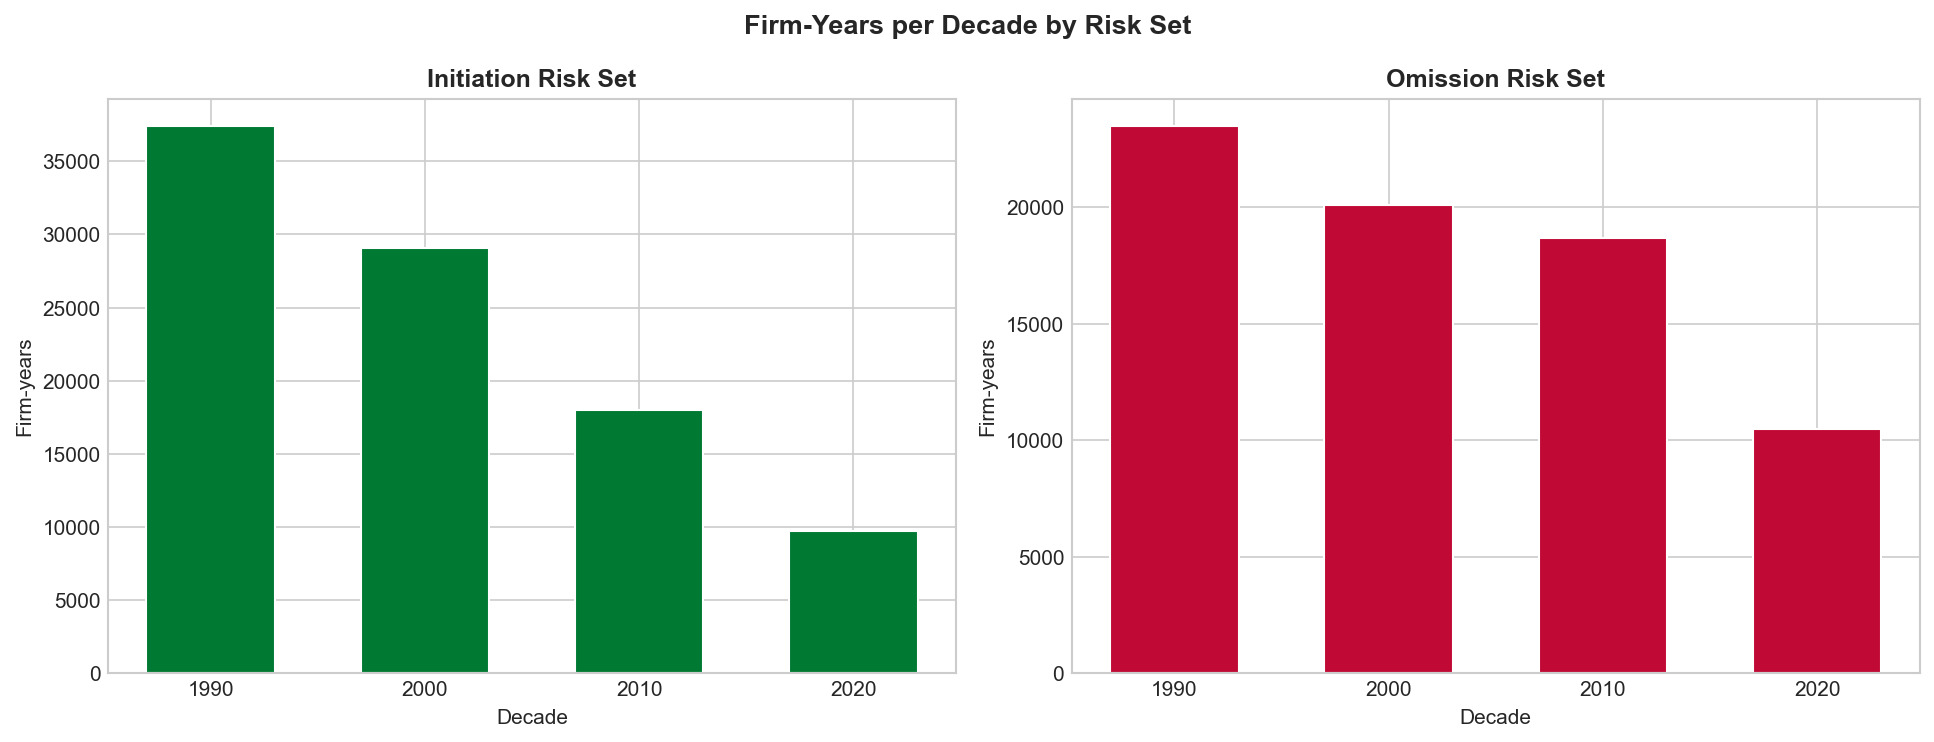

Saved: fig_S1_sample_composition.png


In [8]:
def composition_row(df, target_col, label):
    return {
        'Sample': label,
        'Total firm-years': f"{len(df):,}",
        'Event firm-years': f"{int(df[target_col].sum()):,}",
        'Event rate (%)': f"{100 * df[target_col].mean():.2f}",
        'Unique firms': f"{df['FirmID'].nunique():,}",
        'Year range': f"{int(df['FiscalYear'].min())}–{int(df['FiscalYear'].max())}",
    }

comp_table = pd.DataFrame([
    composition_row(init_desc, 'target_initiation', 'Initiation'),
    composition_row(omit_desc, 'target_omission',   'Omission'),
]).set_index('Sample')

print('Sample Composition')
print('=' * 60)
display(comp_table)

def decade_counts(df, label):
    df = df.copy()
    df['Decade'] = (df['FiscalYear'] // 10) * 10
    counts = df.groupby('Decade').size().reset_index(name='Firm-years')
    counts['Sample'] = label
    return counts

init_dec = decade_counts(init_desc, 'Initiation')
omit_dec = decade_counts(omit_desc, 'Omission')

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=150, sharey=False)

axes[0].bar(init_dec['Decade'].astype(str), init_dec['Firm-years'],
            color=UU_GREEN, edgecolor='white', width=0.6)
axes[0].set_title('Initiation Risk Set', fontweight='bold')
axes[0].set_xlabel('Decade')
axes[0].set_ylabel('Firm-years')

axes[1].bar(omit_dec['Decade'].astype(str), omit_dec['Firm-years'],
            color=UU_RED, edgecolor='white', width=0.6)
axes[1].set_title('Omission Risk Set', fontweight='bold')
axes[1].set_xlabel('Decade')
axes[1].set_ylabel('Firm-years')

fig.suptitle('Firm-Years per Decade by Risk Set', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_S1_sample_composition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_S1_sample_composition.png')

## Section 5 — Annual Event Counts and Rates

Per-year event totals with crisis shading. Initiation and omission counts on the same axis make the counter-cyclical pattern visible: omissions spike during recessions (GFC, COVID) while initiations cluster in expansionary periods.

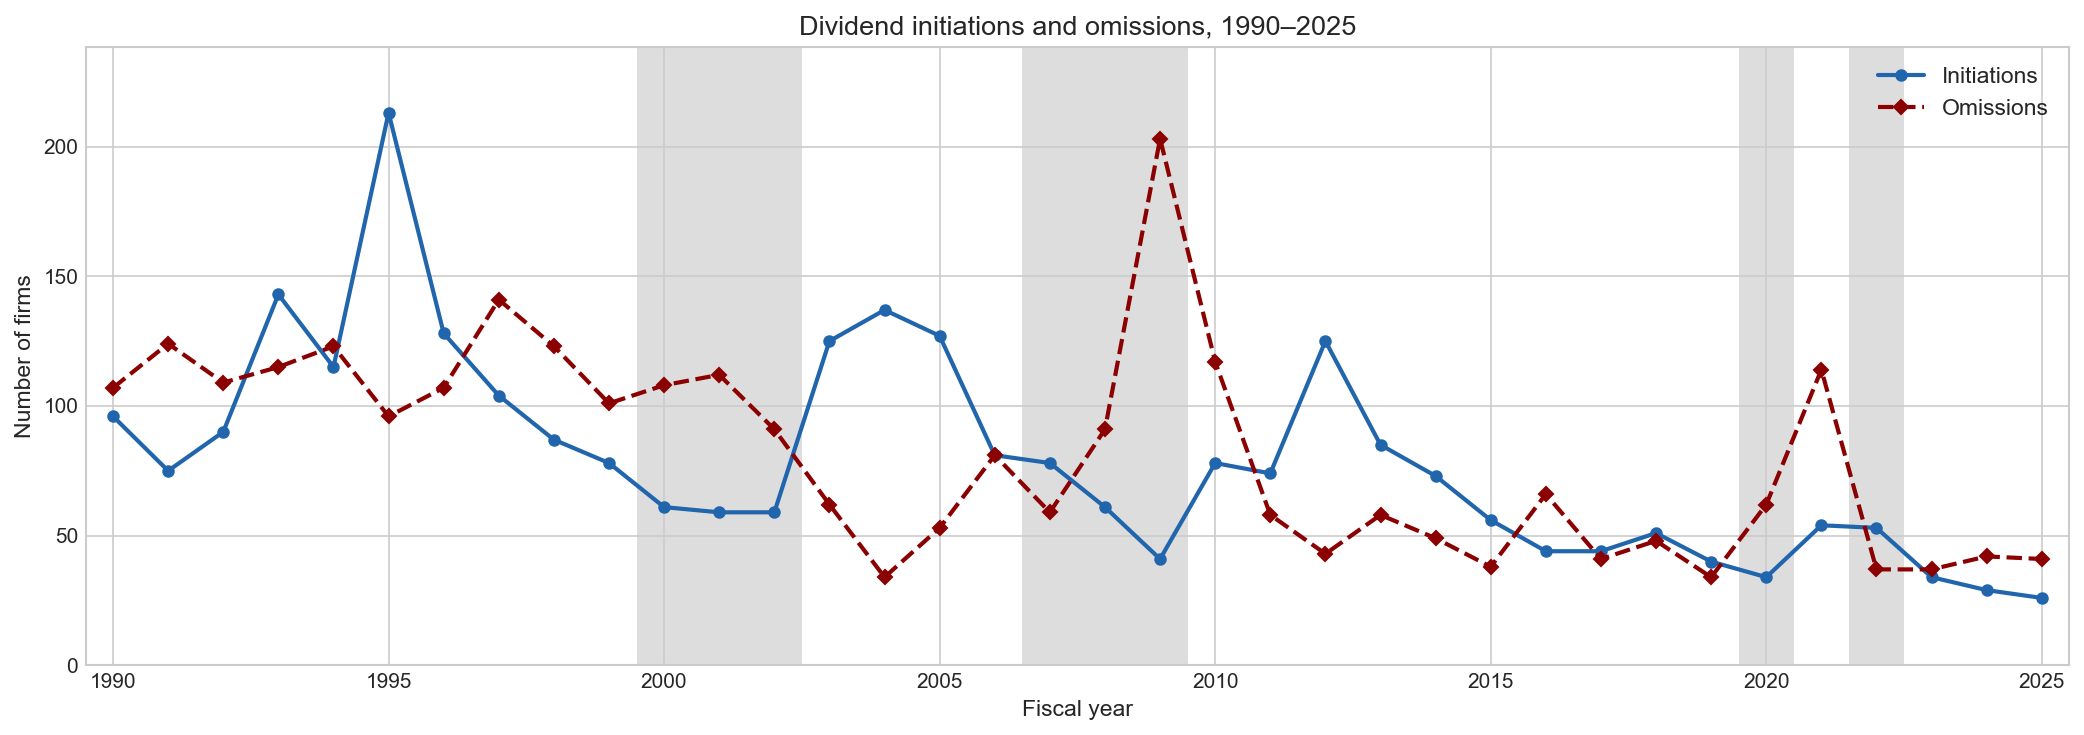

Saved: fig1_event_counts_time_series.png
Saved: /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/tab_A1_annual_event_counts.tex

Annual table (last 10 years):


,Init N,Init Events,Init Rate (%),Omit N,Omit Events,Omit Rate (%)
FiscalYear,,,,,,
2016,1600,44,2.7500,2011,66,3.2800
2017,1596,44,2.7600,1966,41,2.0900
2018,1572,51,3.2400,1909,48,2.5100
2019,1545,40,2.5900,1885,34,1.8000
2020,1609,34,2.1100,1881,62,3.3000
2021,1885,54,2.8600,1810,114,6.3000
2022,1791,53,2.9600,1697,37,2.1800
2023,1641,34,2.0700,1741,37,2.1300
2024,1495,29,1.9400,1768,42,2.3800


In [9]:
def to_latex_booktabs(df, path, caption='', label=''):
    """Save df to a booktabs-style .tex file."""
    import inspect
    # pandas >= 1.3 supports hrules kwarg
    sig = inspect.signature(df.to_latex)
    if 'hrules' in sig.parameters:
        tex = df.to_latex(
            index=True,
            escape=True,
            caption=caption,
            label=label,
            column_format='l' + 'r' * len(df.columns),
            hrules=True,
        )
    else:
        tex = df.to_latex(
            index=True,
            escape=True,
            caption=caption,
            label=label,
            column_format='l' + 'r' * len(df.columns),
        )
        # Inject booktabs rules manually if not present
        if '\\toprule' not in tex:
            tex = tex.replace('\\hline', '')
            lines = tex.split('\n')
            out = []
            for line in lines:
                out.append(line)
                if '\\begin{tabular}' in line:
                    out.append('\\toprule')
            tex = '\n'.join(out)
            tex = tex.replace('\\end{tabular}', '\\bottomrule\n\\end{tabular}')
    with open(path, 'w') as fh:
        fh.write(tex)
    print(f'Saved: {path}')


def add_crisis_shading(ax):
    ymin, ymax = ax.get_ylim()
    for name, start, end, color, alpha in CRISES:
        ax.axvspan(start - 0.5, end + 0.5, color=color, alpha=alpha, lw=0, zorder=0)
        ax.text(
            (start + end) / 2, ymax * 0.97, name,
            ha='center', va='top', fontsize=8, color=color, fontweight='bold'
        )


def annual_stats(df, target_col):
    g = df.groupby('FiscalYear')[target_col]
    out = pd.DataFrame({
        'N': g.count(),
        'Events': g.sum().astype(int),
    })
    out['Event_rate_pct'] = 100 * out['Events'] / out['N']
    return out

init_annual = annual_stats(init_desc, 'target_initiation')
omit_annual = annual_stats(omit_desc, 'target_omission')

CRISES_GRAY = [
    ('Dot-com',    2000, 2002),
    ('GFC',        2007, 2009),
    ('COVID',      2020, 2020),
    ('Rate Shock', 2022, 2022),
]

fig, ax = plt.subplots(figsize=(14, 5), dpi=150)

# Initiations — blue solid line, circle markers
ax.plot(init_annual.index, init_annual['Events'],
        color='#2166AC', lw=2, marker='o', ms=5, label='Initiations', zorder=3)

# Omissions — dark red dashed line, diamond markers
ax.plot(omit_annual.index, omit_annual['Events'],
        color='#8B0000', lw=2, marker='D', ms=5, ls='--',
        label='Omissions', zorder=3)

# Gray crisis shading
ymin, ymax = 0, max(init_annual['Events'].max(), omit_annual['Events'].max()) * 1.12
ax.set_ylim(ymin, ymax)
for cname, start, end in CRISES_GRAY:
    ax.axvspan(start - 0.5, end + 0.5, color='#CCCCCC', alpha=0.65, lw=0, zorder=0)

ax.set_title('Dividend initiations and omissions, 1990\u20132025', fontsize=13)
ax.set_xlabel('Fiscal year', fontsize=11)
ax.set_ylabel('Number of firms', fontsize=11)
ax.legend(fontsize=11, loc='upper right')
ax.set_xlim(init_annual.index.min() - 0.5, init_annual.index.max() + 0.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig1_event_counts_time_series.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_event_counts_time_series.png')

tab_a1 = init_annual.copy()
tab_a1.columns = ['Init N', 'Init Events', 'Init Rate (%)']
tab_a1[['Omit N', 'Omit Events', 'Omit Rate (%)']] = omit_annual[['N', 'Events', 'Event_rate_pct']].values
tab_a1['Init Events']  = tab_a1['Init Events'].astype(int)
tab_a1['Omit Events']  = tab_a1['Omit Events'].astype(int)
tab_a1['Init N']       = tab_a1['Init N'].astype(int)
tab_a1['Omit N']       = tab_a1['Omit N'].astype(int)
tab_a1 = tab_a1.round({'Init Rate (%)': 2, 'Omit Rate (%)': 2})

to_latex_booktabs(
    tab_a1, TABLES_DIR / 'tab_A1_annual_event_counts.tex',
    caption='Annual event counts and rates for the initiation and omission risk sets, 1990--2025.',
    label='tab:A1_annual_events',
)

print('\nAnnual table (last 10 years):')
display(tab_a1.tail(10))

## Section 6 — Full Summary Statistics (Appendix)

N, mean, SD, and percentiles (P5–P95) for every current-year variable, split by event status. `DIVPREM` is shown full-sample only because it is market-wide. These appendix tables document the raw distributional properties before any modelling transformation.

In [10]:
def summary_stats(df, features):
    """Return N, mean, SD, P5, P25, median, P75, P95 for each feature."""
    rows = []
    for f in features:
        if f not in df.columns:
            continue
        s = df[f].dropna()
        rows.append({
            'Variable': f,
            'N': len(s),
            'Mean': s.mean(),
            'SD': s.std(),
            'P5': s.quantile(0.05),
            'P25': s.quantile(0.25),
            'Median': s.median(),
            'P75': s.quantile(0.75),
            'P95': s.quantile(0.95),
        })
    return pd.DataFrame(rows).set_index('Variable').round(4)


def split_sumstats(df, target_col, features):
    """Compute summary stats split by event / non-event."""
    # Separate market-wide vars (no event split) from firm-level vars
    firm_feats   = [f for f in features if f not in MARKET_WIDE and f in df.columns]
    market_feats = [f for f in features if f in MARKET_WIDE and f in df.columns]

    non_event_df = df[df[target_col] == 0]
    event_df     = df[df[target_col] == 1]

    stats_ne  = summary_stats(non_event_df, firm_feats)
    stats_ev  = summary_stats(event_df,     firm_feats)
    stats_mkt = summary_stats(df,           market_feats)   # full-sample only

    return stats_ne, stats_ev, stats_mkt


ne_init, ev_init, mkt_init = split_sumstats(init_desc, 'target_initiation', available_features)

# Combine with multi-level header for the LaTeX file
combined_init = pd.concat(
    [ne_init, ev_init],
    keys=['Non-Initiators', 'Initiators'],
    axis=0
)
if not mkt_init.empty:
    combined_init = pd.concat([combined_init, pd.concat([mkt_init], keys=['Full Sample (market-wide)'], axis=0)])

to_latex_booktabs(
    combined_init, TABLES_DIR / 'tab_A3_sumstats_initiation.tex',
    caption='Summary statistics for current-year characteristics in the initiation risk set, split by event status. DIVPREM is market-wide and shown full-sample only.',
    label='tab:A3_sumstats_init',
)

ne_omit, ev_omit, mkt_omit = split_sumstats(omit_desc, 'target_omission', available_features)

combined_omit = pd.concat(
    [ne_omit, ev_omit],
    keys=['Non-Omitters', 'Omitters'],
    axis=0
)
if not mkt_omit.empty:
    combined_omit = pd.concat([combined_omit, pd.concat([mkt_omit], keys=['Full Sample (market-wide)'], axis=0)])

to_latex_booktabs(
    combined_omit, TABLES_DIR / 'tab_A4_sumstats_omission.tex',
    caption='Summary statistics for current-year characteristics in the omission risk set, split by event status. DIVPREM is market-wide and shown full-sample only.',
    label='tab:A4_sumstats_omit',
)

print('\nInitiation — Initiators summary (first 10 rows):')
display(ev_init.head(10))
print('\nOmission — Omitters summary (first 10 rows):')
display(ev_omit.head(10))

Saved: /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/tab_A3_sumstats_initiation.tex
Saved: /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/tab_A4_sumstats_omission.tex

Initiation — Initiators summary (first 10 rows):


,N,Mean,SD,P5,P25,Median,P75,P95
Variable,,,,,,,,
RE_TE,2682,-0.4928,7.1344,-3.2117,-0.0583,0.2245,0.5811,0.9831
RE_TA,2682,-0.1534,2.0112,-1.1012,-0.0151,0.0506,0.1925,0.5878
TE_TA,2858,0.4168,0.2675,0.0635,0.1710,0.3820,0.6338,0.8788
Size,2858,5.8178,2.0992,2.3053,4.4012,5.8746,7.2181,9.1018
Log_MarketCap,2299,5.5330,2.1356,2.1827,4.0855,5.5331,6.8863,9.0105
Sales_Growth,2268,0.8572,15.0072,-0.2273,0.0120,0.1219,0.2954,1.2050
Asset_Growth,2268,0.3279,1.3419,-0.2280,-0.0049,0.0999,0.2803,1.3475
Listing_Age,2858,7.7680,7.4589,2.0000,3.0000,4.0000,10.0000,24.0000
Market_to_Book,2299,1.9904,2.7705,0.8394,1.0248,1.3182,2.0438,5.0733



Omission — Omitters summary (first 10 rows):


,N,Mean,SD,P5,P25,Median,P75,P95
Variable,,,,,,,,
RE_TE,2842,-1.1618,17.9923,-3.2838,-0.2173,0.2071,0.5525,0.9874
RE_TA,2842,-0.0351,1.2830,-0.6306,-0.0432,0.0486,0.1860,0.5332
TE_TA,2925,0.3714,0.2538,0.0428,0.1522,0.3290,0.5487,0.8523
Size,2925,6.0410,2.1469,2.6723,4.4936,5.9522,7.5502,9.5299
Log_MarketCap,2502,4.6586,2.0359,1.5076,3.2248,4.4922,6.0433,8.0780
Sales_Growth,2828,0.1821,2.9219,-0.3654,-0.1035,0.0231,0.1906,0.8008
Asset_Growth,2828,0.1732,1.1418,-0.2944,-0.0838,0.0111,0.1425,0.9500
Listing_Age,2925,17.2297,14.2753,2.0000,5.0000,13.0000,27.0000,46.0000
Market_to_Book,2502,1.5174,2.0956,0.6783,0.9418,1.0549,1.4901,3.5385


## Section 7 — Mean Comparison by Event Status

For each theory block, compare the mean of every firm-level variable between event and non-event groups using Mann–Whitney U tests (two-sided). These univariate comparisons identify which predictors discriminate before any multivariate modelling. `DIVPREM` is excluded because it is identical for both groups within a fiscal year.

In [11]:
def stars(p):
    if p < 0.01:  return '***'
    if p < 0.05:  return '**'
    if p < 0.10:  return '*'
    return ''


def block_comparison_table(df, target_col, event_label, non_event_label):
    """
    For every theory block, compute mean (SD) for event vs non-event,
    mean difference, and MW p-value. Returns a single DataFrame covering all blocks.
    """
    event_df    = df[df[target_col] == 1]
    non_event_df= df[df[target_col] == 0]

    rows = []
    for block_name, block_vars in THEORY_BLOCKS.items():
        for var in block_vars:
            if var in MARKET_WIDE:
                continue           # skip market-wide vars — no event split
            if var not in df.columns:
                continue

            ev  = event_df[var].dropna()
            ne  = non_event_df[var].dropna()

            ev_mean  = ev.mean()
            ev_sd    = ev.std()
            ne_mean  = ne.mean()
            ne_sd    = ne.std()
            diff     = ev_mean - ne_mean

            if len(ev) > 0 and len(ne) > 0:
                stat, pval = mannwhitneyu(ev, ne, alternative='two-sided', nan_policy='omit')
            else:
                pval = np.nan

            rows.append({
                'Block': block_name,
                'Variable': var,
                f'{non_event_label} mean': ne_mean,
                f'{non_event_label} SD':   ne_sd,
                f'{event_label} mean':     ev_mean,
                f'{event_label} SD':       ev_sd,
                'Diff': diff,
                'MW p-value': pval,
                'Stars': stars(pval),
            })

    return pd.DataFrame(rows)


def format_comparison_table(raw_df, event_label, non_event_label):
    """Format the raw comparison df for display and LaTeX export."""
    out = raw_df.copy()
    ne_mean_col = f'{non_event_label} mean'
    ne_sd_col   = f'{non_event_label} SD'
    ev_mean_col = f'{event_label} mean'
    ev_sd_col   = f'{event_label} SD'

    out[f'{non_event_label} mean (SD)'] = (
        out[ne_mean_col].map('{:.3f}'.format) + ' (' +
        out[ne_sd_col].map('{:.3f}'.format) + ')'
    )
    out[f'{event_label} mean (SD)'] = (
        out[ev_mean_col].map('{:.3f}'.format) + ' (' +
        out[ev_sd_col].map('{:.3f}'.format) + ')'
    )
    out['Diff'] = out['Diff'].map('{:.3f}'.format)
    out['MW p-value'] = out['MW p-value'].map(lambda x: f'{x:.3f}' if pd.notna(x) else '')
    out['Sig'] = out['Stars']

    keep_cols = ['Block', 'Variable',
                 f'{non_event_label} mean (SD)', f'{event_label} mean (SD)',
                 'Diff', 'MW p-value', 'Sig']
    return out[keep_cols].set_index(['Block', 'Variable'])


init_raw_comp = block_comparison_table(init_desc, 'target_initiation',
                                       'Initiator', 'Non-Initiator')
omit_raw_comp = block_comparison_table(omit_desc, 'target_omission',
                                       'Omitter', 'Non-Omitter')

init_comp_fmt = format_comparison_table(init_raw_comp, 'Initiator', 'Non-Initiator')
omit_comp_fmt = format_comparison_table(omit_raw_comp, 'Omitter',   'Non-Omitter')

to_latex_booktabs(
    init_comp_fmt, TABLES_DIR / 'tab1_means_initiation.tex',
    caption='Mean characteristics by event status in the initiation risk set. Columns show mean (standard deviation) for non-initiators and initiators, the raw mean difference, and the Mann-Whitney U test p-value. Significance: *** p<0.01, ** p<0.05, * p<0.10.',
    label='tab:1_means_init',
)
to_latex_booktabs(
    omit_comp_fmt, TABLES_DIR / 'tab2_means_omission.tex',
    caption='Mean characteristics by event status in the omission risk set. Columns show mean (standard deviation) for non-omitters and omitters, the raw mean difference, and the Mann-Whitney U test p-value. Significance: *** p<0.01, ** p<0.05, * p<0.10.',
    label='tab:2_means_omit',
)

print('\nTable 1 — Mean comparison, initiation sample:')
display(init_comp_fmt)

print('\nTable 2 — Mean comparison, omission sample:')
display(omit_comp_fmt)

Saved: /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/tab1_means_initiation.tex
Saved: /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/tab2_means_omission.tex

Table 1 — Mean comparison, initiation sample:


Non-Initiator mean (SD)            Initiator mean (SD)          Diff MW p-value  Sig
Block                          Variable                                                                                                      
1. Life-Cycle & Maturity       RE_TE                          -14.429 (1162.658)                 -0.493 (7.134)        13.936      0.000  ***
                               RE_TA                              -1.548 (9.893)                 -0.153 (2.011)         1.395      0.000  ***
                               TE_TA                               0.514 (0.265)                  0.417 (0.268)        -0.097      0.000  ***
                               Size                                4.442 (2.196)                  5.818 (2.099)         1.375      0.000  ***
                               Log_MarketCap                       4.525 (2.221)                  5.533 (2.136)         1.008      0.000  ***
                               Sales_Growth                       1.873 (71.811)                 0.857 (15.007)        -1.015      0.145     
                               Asset_Growth                        0.439 (8.609)                  0.328 (1.342)        -0.112      0.000  ***
                               Listing_Age                         9.122 (7.986)                  7.768 (7.459)        -1.354      0.000  ***
2. Growth Options & Investment Market_to_Book                   9.292 (1060.511)                  1.990 (2.771)        -7.302      0.000  ***
                               CapEx_to_Assets                     0.055 (0.093)                  0.050 (0.076)        -0.005      0.000  ***
                               RD_assets                           0.086 (0.234)                  0.020 (0.078)        -0.066      0.000  ***
                               Price_to_Sales                192.117 (20585.625)               16.370 (376.565)      -175.747      0.000  ***
3. Signaling & Profitability   ROA                                -0.160 (1.326)                  0.043 (0.259)         0.203      0.000  ***
                               ROE                              -1.441 (134.527)                 0.323 (11.778)         1.764      0.000  ***
                               OpCF_to_Assets                     -0.059 (0.417)                  0.076 (0.327)         0.135      0.000  ***
                               ORA                                -0.067 (1.070)                  0.117 (0.200)         0.184      0.000  ***
                               Profit_Margin                   -10.989 (228.895)                -0.479 (23.987)        10.510      0.000  ***
                               Accruals                           -0.102 (1.088)                 -0.032 (0.319)         0.070      0.000  ***
4. Free Cash Flow & Agency     Cash_to_Assets                      0.254 (0.263)                  0.155 (0.197)        -0.098      0.000  ***
                               FCF_to_Assets                      -0.114 (0.426)                  0.026 (0.327)         0.140      0.000  ***
                               Repurchase_to_Assets                0.012 (0.088)                  0.021 (0.110)         0.009      0.000  ***
                               Goodwill_to_Assets                  0.074 (0.141)                  0.073 (0.137)        -0.001      0.002  ***
5. Conservatism & Risk         Leverage                            0.197 (0.211)                  0.229 (0.231)         0.033      0.000  ***
                               LTDA                                0.142 (0.188)                  0.180 (0.210)         0.038      0.000  ***
                               Current_Ratio                      4.367 (88.109)                  2.914 (4.481)        -1.453      0.000  ***
                               Earnings_Volatility                 0.151 (0.841)                  0.066 (0.193)        -0.085      0.000  ***
                               Interest_Coverage              -44.357 (1810.707) 


Table 2 — Mean comparison, omission sample:


Non-Omitter mean (SD)             Omitter mean (SD)           Diff MW p-value  Sig
Block                          Variable                                                                                                        
1. Life-Cycle & Maturity       RE_TE                                 0.468 (9.721)               -1.162 (17.992)         -1.630      0.000  ***
                               RE_TA                                 0.190 (0.405)                -0.035 (1.283)         -0.225      0.000  ***
                               TE_TA                                 0.348 (0.230)                 0.371 (0.254)          0.023      0.002  ***
                               Size                                  7.409 (2.058)                 6.041 (2.147)         -1.368      0.000  ***
                               Log_MarketCap                         6.659 (2.181)                 4.659 (2.036)         -2.001      0.000  ***
                               Sales_Growth                          0.104 (1.197)                 0.182 (2.922)          0.078      0.000  ***
                               Asset_Growth                          0.116 (1.080)                 0.173 (1.142)          0.058      0.000  ***
                               Listing_Age                         23.423 (15.013)               17.230 (14.275)         -6.194      0.000  ***
2. Growth Options & Investment Market_to_Book                       1.926 (18.747)                 1.517 (2.096)         -0.409      0.000  ***
                               CapEx_to_Assets                       0.040 (0.052)                 0.046 (0.071)          0.006      0.000  ***
                               RD_assets                             0.007 (0.024)                 0.011 (0.036)          0.003      0.336     
                               Price_to_Sales                        2.433 (9.798)               8.937 (337.339)          6.503      0.000  ***
3. Signaling & Profitability   ROA                                   0.079 (1.896)                -0.020 (0.186)         -0.098      0.000  ***
                               ROE                                  0.396 (14.543)               -0.630 (12.162)         -1.027      0.000  ***
                               OpCF_to_Assets                        0.082 (0.124)                 0.043 (0.185)         -0.039      0.000  ***
                               ORA                                   0.146 (1.961)                 0.064 (0.168)         -0.082      0.000  ***
                               Profit_Margin                         0.104 (1.534)               -0.387 (11.087)         -0.491      0.000  ***
                               Accruals                             -0.037 (0.109)                -0.063 (0.234)         -0.026      0.000  ***
4. Free Cash Flow & Agency     Cash_to_Assets                        0.084 (0.122)                 0.117 (0.157)          0.032      0.000  ***
                               FCF_to_Assets                         0.042 (0.124)                -0.003 (0.192)         -0.045      0.000  ***
                               Repurchase_to_Assets                  0.014 (0.041)                 0.009 (0.079)         -0.004      0.000  ***
                               Goodwill_to_Assets                    0.057 (0.109)                 0.061 (0.122)          0.004      0.000  ***
5. Conservatism & Risk         Leverage                              0.249 (0.199)                 0.284 (0.232)          0.035      0.000  ***
                               LTDA                                  0.199 (0.180)                 0.223 (0.212)          0.024      0.014   **
                               Current_Ratio                        2.355 (15.932)                 2.473 (5.133)          0.118      0.000  ***
                               Earnings_Volatility                   0.036 (0.767)                 0.077 (0.260)          0.041      0.000  ***
                             

## Section 8 — Visual: Mean Differences by Theory Block

Standardise each variable to z-scores (full-sample mean and SD) so all variables are on a comparable scale. The grouped bar chart shows event vs. non-event group means per theory block, with significance stars from the Mann–Whitney tests above.

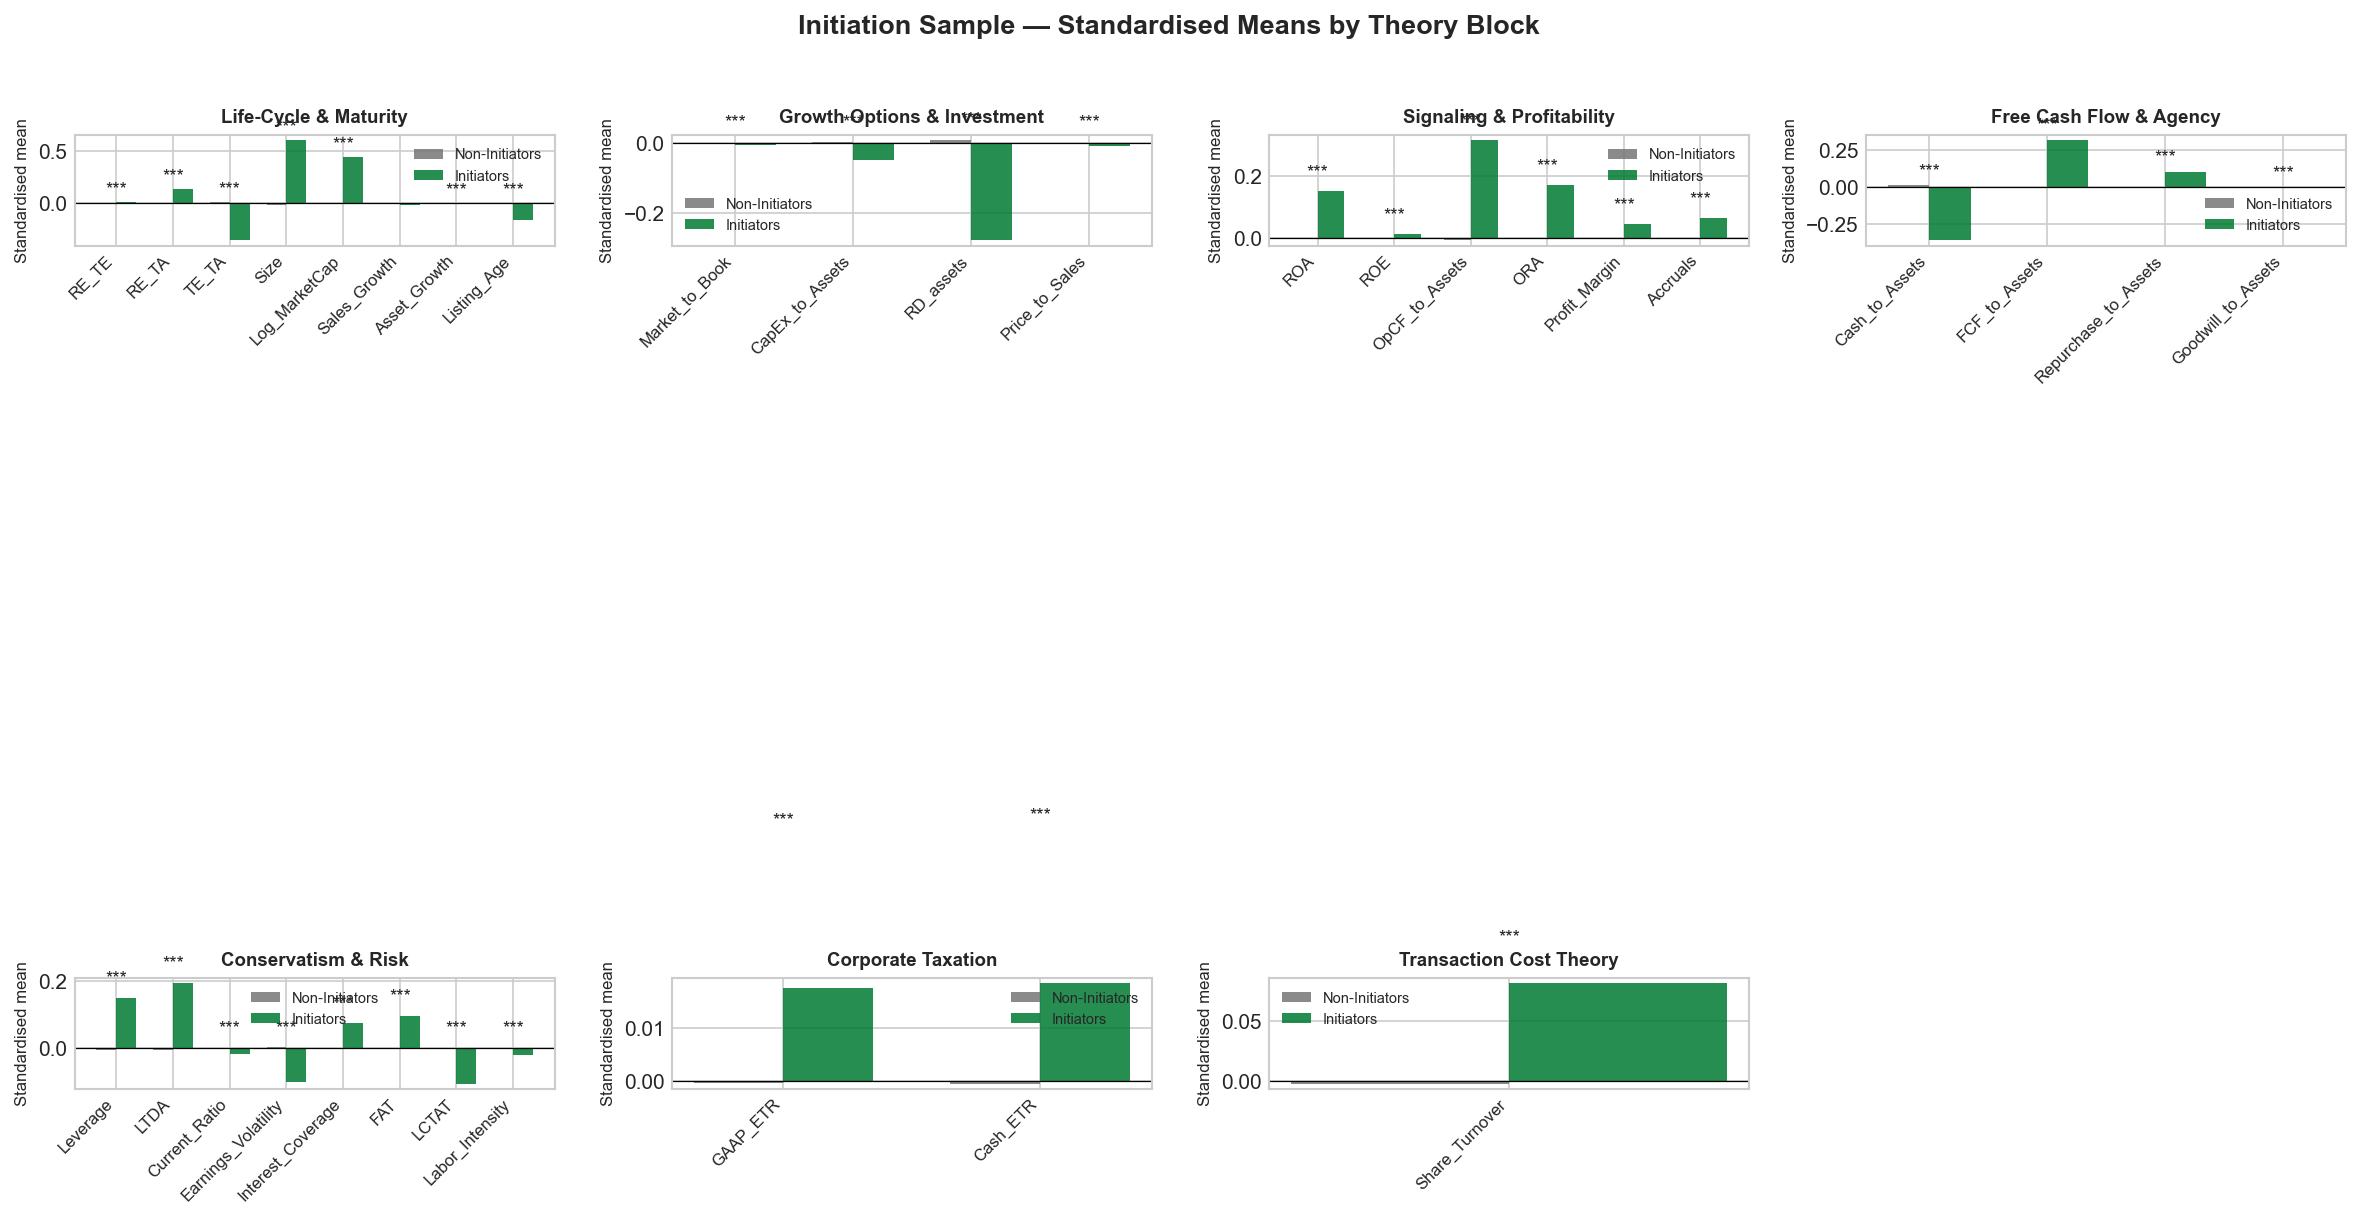

Saved: /Users/matyaslezatka/Documents/Thesis/Submission/results/figures/fig2_mean_diff_initiation.png


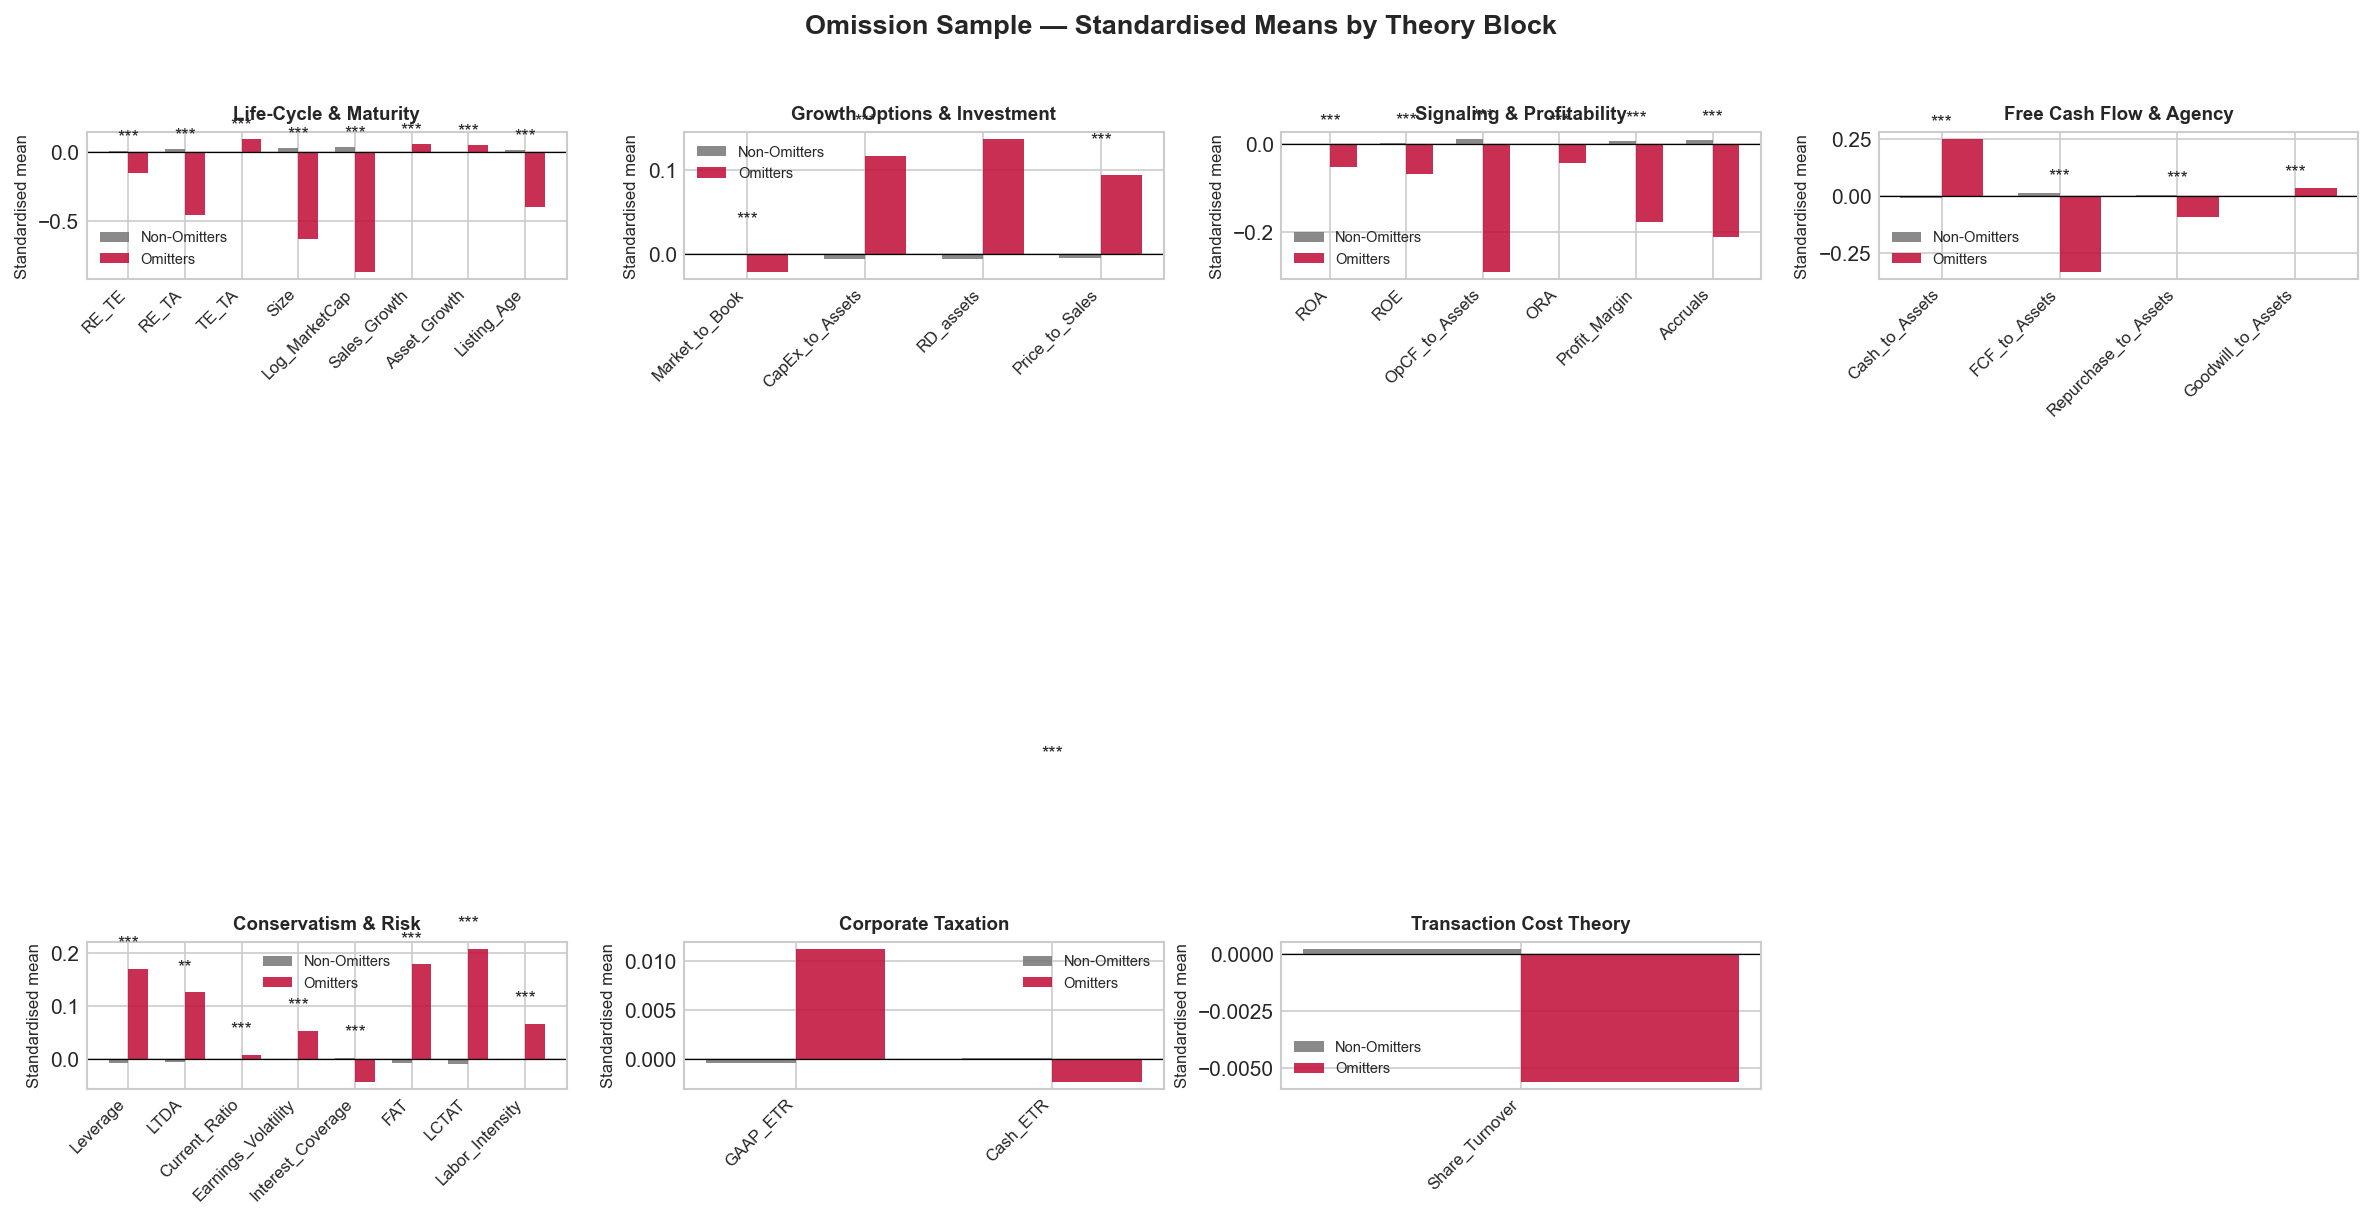

Saved: /Users/matyaslezatka/Documents/Thesis/Submission/results/figures/fig3_mean_diff_omission.png


In [12]:
def plot_block_grid(df, raw_comp, target_col, event_label, non_event_label,
                    event_color, fig_title, save_path):
    """
    One subplot per theory block.  Each subplot shows event vs non-event means
    of standardised variables.  Significance stars are annotated above bars.
    """
    # Keep only blocks that have at least one non-market-wide var available
    blocks_to_plot = [
        (bname, [v for v in bvars if v not in MARKET_WIDE and v in df.columns])
        for bname, bvars in THEORY_BLOCKS.items()
    ]
    blocks_to_plot = [(b, v) for b, v in blocks_to_plot if v]

    n_blocks = len(blocks_to_plot)
    ncols = 4
    nrows = int(np.ceil(n_blocks / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4), dpi=150)
    axes = axes.flatten()

    # Pre-compute global z-score parameters per variable
    all_vars = [v for bname, bvars in blocks_to_plot for v in bvars]
    zmean = {v: df[v].mean() for v in all_vars}
    zstd  = {v: df[v].std()  for v in all_vars}

    # Build MW lookup: variable -> p-value and stars
    mw_lookup = dict(zip(raw_comp['Variable'], zip(raw_comp['MW p-value'], raw_comp['Stars'])))

    event_df    = df[df[target_col] == 1]
    non_event_df= df[df[target_col] == 0]

    for idx, (block_name, block_vars) in enumerate(blocks_to_plot):
        ax = axes[idx]
        x = np.arange(len(block_vars))
        width = 0.35

        ne_means = []
        ev_means = []
        sig_marks = []

        for v in block_vars:
            sd = zstd[v] if zstd[v] != 0 else 1.0
            ne_means.append((non_event_df[v].mean() - zmean[v]) / sd)
            ev_means.append((event_df[v].mean()     - zmean[v]) / sd)
            pval, sig = mw_lookup.get(v, (np.nan, ''))
            sig_marks.append(sig)

        bars_ne = ax.bar(x - width/2, ne_means, width, color=UU_GRAY,
                         label=non_event_label, alpha=0.85)
        bars_ev = ax.bar(x + width/2, ev_means, width, color=event_color,
                         label=event_label, alpha=0.85)
        ax.axhline(0, color='black', lw=0.6)

        # Annotate significance stars above the taller bar
        for i, sig in enumerate(sig_marks):
            if sig:
                top = max(ne_means[i], ev_means[i])
                ax.text(x[i], top + 0.03, sig, ha='center', va='bottom', fontsize=9)

        short_block = block_name.split('. ', 1)[-1]  # remove number prefix
        ax.set_title(short_block, fontsize=9, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(block_vars, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('Standardised mean', fontsize=8)
        ax.legend(fontsize=7)

    # Hide unused subplots
    for idx in range(len(blocks_to_plot), len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(fig_title, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


plot_block_grid(
    init_desc, init_raw_comp, 'target_initiation',
    'Initiators', 'Non-Initiators', UU_GREEN,
    'Initiation Sample — Standardised Means by Theory Block',
    FIGURES_DIR / 'fig2_mean_diff_initiation.png',
)

plot_block_grid(
    omit_desc, omit_raw_comp, 'target_omission',
    'Omitters', 'Non-Omitters', UU_RED,
    'Omission Sample — Standardised Means by Theory Block',
    FIGURES_DIR / 'fig3_mean_diff_omission.png',
)

## Section 9 — Distribution Comparisons (Violin Plots)

Select the five variables with the largest absolute standardised mean difference (Cohen's d equivalent) for each risk set. Violin plots reveal distributional shape — skewness, bimodality, and overlap — that summary statistics alone cannot capture.

Top-5 initiation variables by |SMD|: ['Size', 'Log_MarketCap', 'Cash_to_Assets', 'TE_TA', 'FCF_to_Assets']
Top-5 omission variables by |SMD|:   ['Log_MarketCap', 'Size', 'RE_TA', 'Listing_Age', 'FCF_to_Assets']


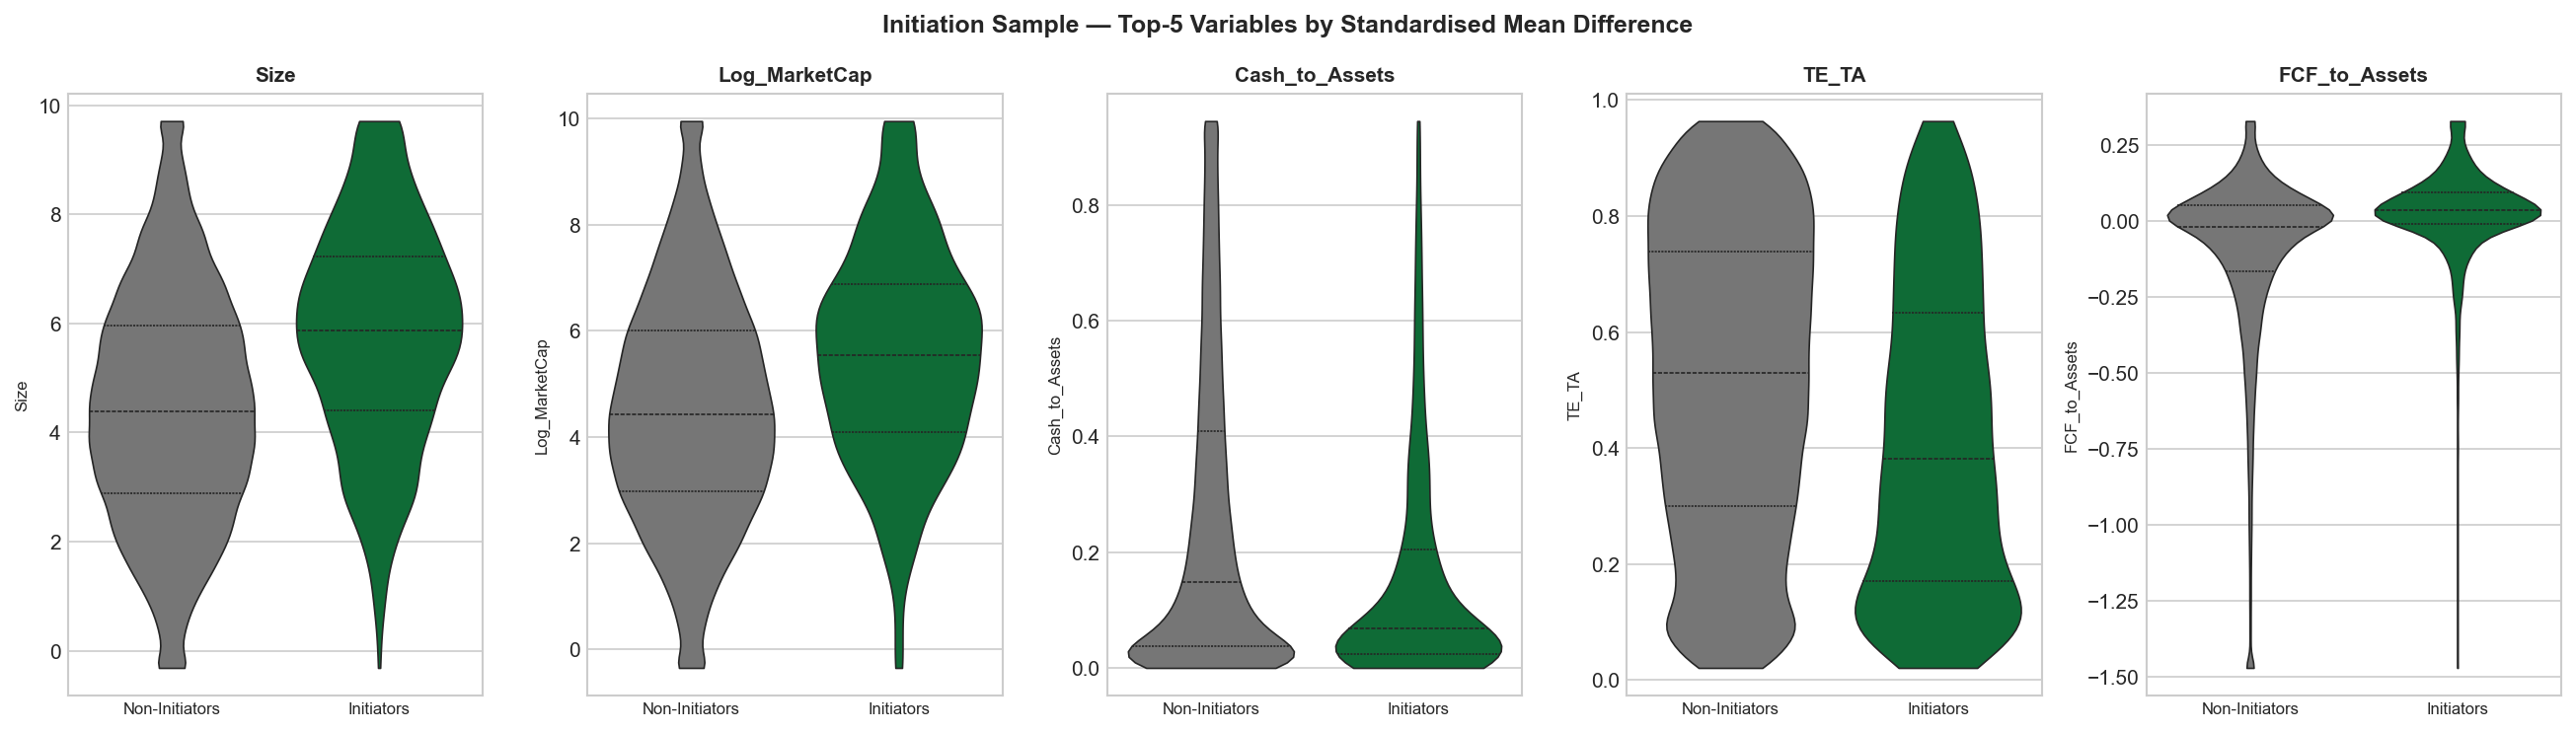

Saved: /Users/matyaslezatka/Documents/Thesis/Submission/results/figures/fig4_violin_initiation.png


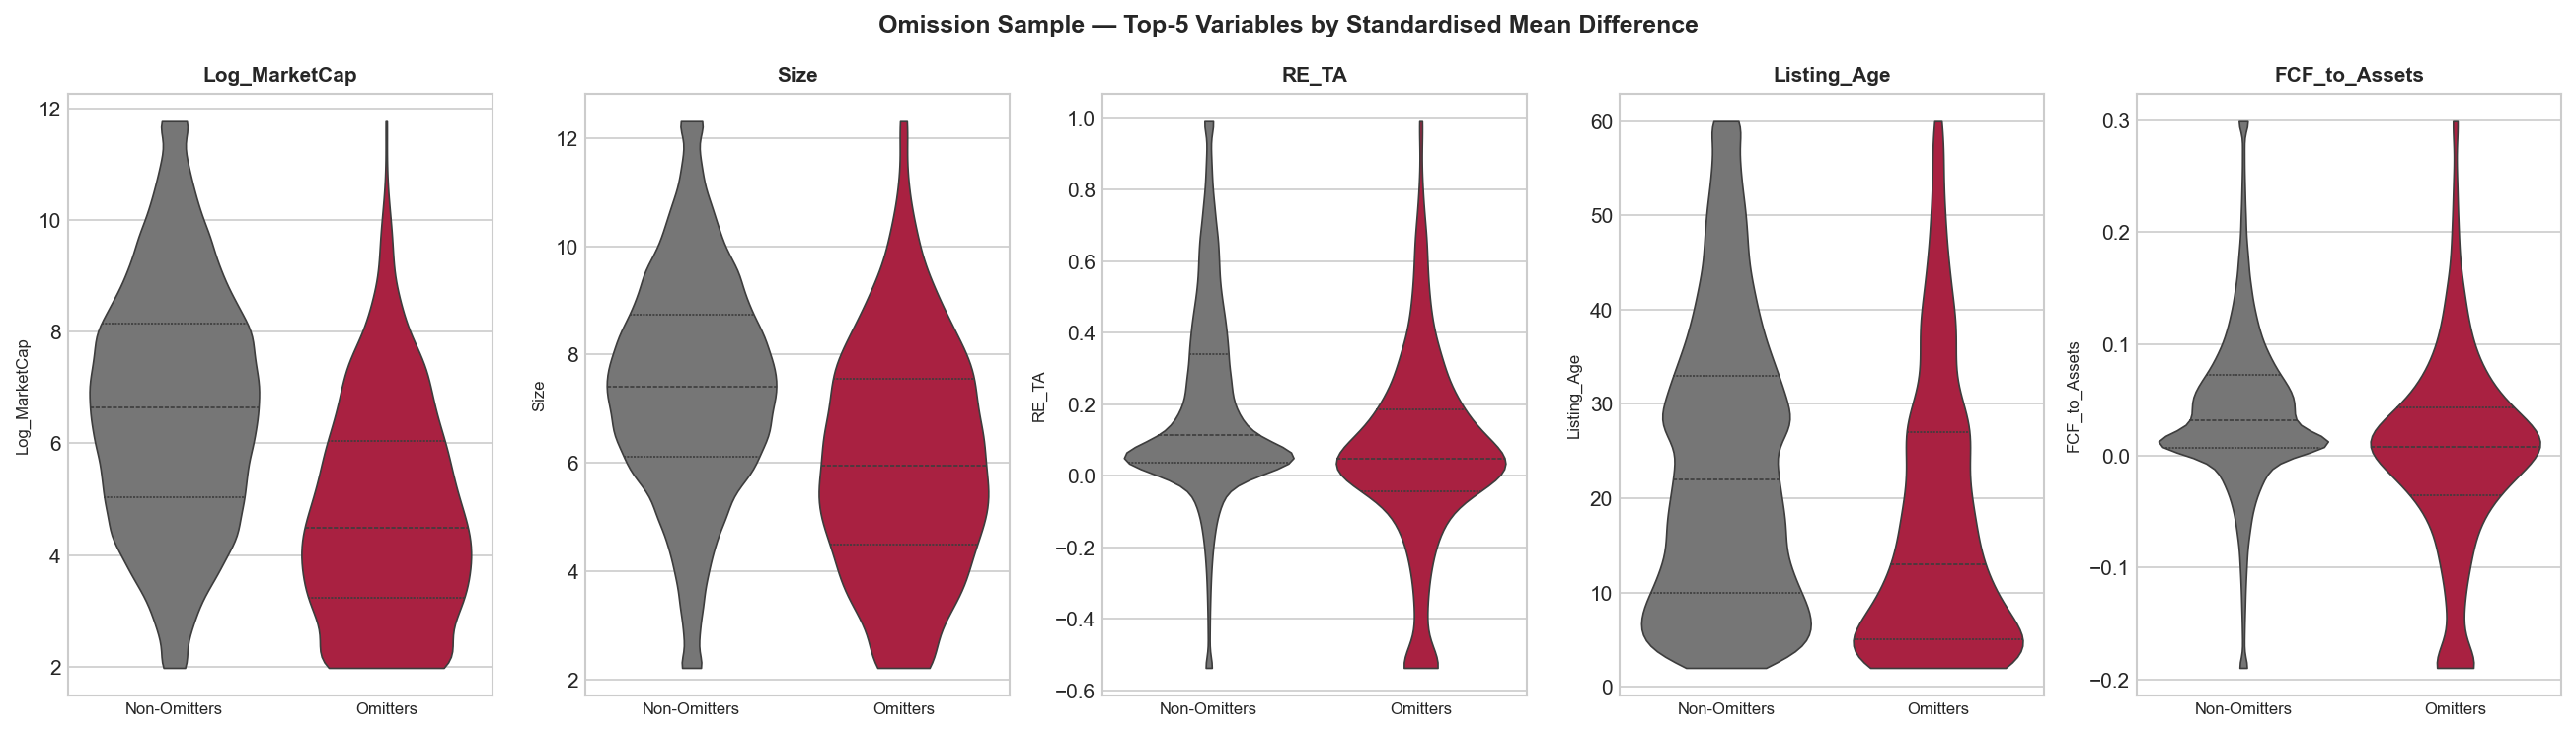

Saved: /Users/matyaslezatka/Documents/Thesis/Submission/results/figures/fig5_violin_omission.png


In [13]:
def top_k_by_smd(raw_comp_df, df, k=5):
    """Return top-k variable names by |standardised mean difference|."""
    # Exclude market-wide vars
    sub = raw_comp_df[~raw_comp_df['Variable'].isin(MARKET_WIDE)].copy()
    # Compute pooled SD from full sample for each variable
    sub['pooled_sd'] = sub['Variable'].map(
        lambda v: df[v].std() if v in df.columns else np.nan
    )
    sub['SMD'] = sub['Diff'].abs() / sub['pooled_sd'].replace(0, np.nan)
    return sub.nlargest(k, 'SMD')['Variable'].tolist()


def violin_figure(df, target_col, vars_list, event_label, non_event_label,
                  event_color, fig_title, save_path):
    n = len(vars_list)
    fig, axes = plt.subplots(1, n, figsize=(3.5 * n, 5), dpi=150)
    if n == 1:
        axes = [axes]

    # Build long-form data for seaborn
    label_map = {0: non_event_label, 1: event_label}
    palette   = {non_event_label: UU_GRAY, event_label: event_color}

    for ax, var in zip(axes, vars_list):
        plot_df = df[['target_' + target_col.split('_')[1], var]].copy()
        plot_df.columns = ['Event', var]
        plot_df['Group'] = plot_df['Event'].map(label_map)
        plot_df = plot_df.dropna(subset=[var])

        # Clip to P1–P99 for visual clarity
        p1, p99 = plot_df[var].quantile(0.01), plot_df[var].quantile(0.99)
        plot_df[var] = plot_df[var].clip(p1, p99)

        sns.violinplot(
            data=plot_df, x='Group', y=var,
            palette=palette, order=[non_event_label, event_label],
            inner='quartile', cut=0, ax=ax, linewidth=0.8,
        )
        ax.set_title(var, fontsize=10, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel(var, fontsize=8)
        ax.tick_params(axis='x', labelsize=8)

    fig.suptitle(fig_title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


init_raw_comp_fil = init_raw_comp[init_raw_comp['Variable'].isin(available_features)]
omit_raw_comp_fil = omit_raw_comp[omit_raw_comp['Variable'].isin(available_features)]

top5_init = top_k_by_smd(init_raw_comp_fil, init_desc, k=5)
top5_omit = top_k_by_smd(omit_raw_comp_fil, omit_desc, k=5)

print('Top-5 initiation variables by |SMD|:', top5_init)
print('Top-5 omission variables by |SMD|:  ', top5_omit)

violin_figure(
    init_desc, 'target_initiation', top5_init,
    'Initiators', 'Non-Initiators', UU_GREEN,
    'Initiation Sample — Top-5 Variables by Standardised Mean Difference',
    FIGURES_DIR / 'fig4_violin_initiation.png',
)

violin_figure(
    omit_desc, 'target_omission', top5_omit,
    'Omitters', 'Non-Omitters', UU_RED,
    'Omission Sample — Top-5 Variables by Standardised Mean Difference',
    FIGURES_DIR / 'fig5_violin_omission.png',
)

## Section 10 — Time Trends in Key Characteristics

Five-year rolling means for six selected variables, split by event status. `DIVPREM` is shown as a single market-wide series. Time trends motivate the rolling-window ML design: if the relationship between features and events shifts over time, a static model trained on the full sample would be misspecified.

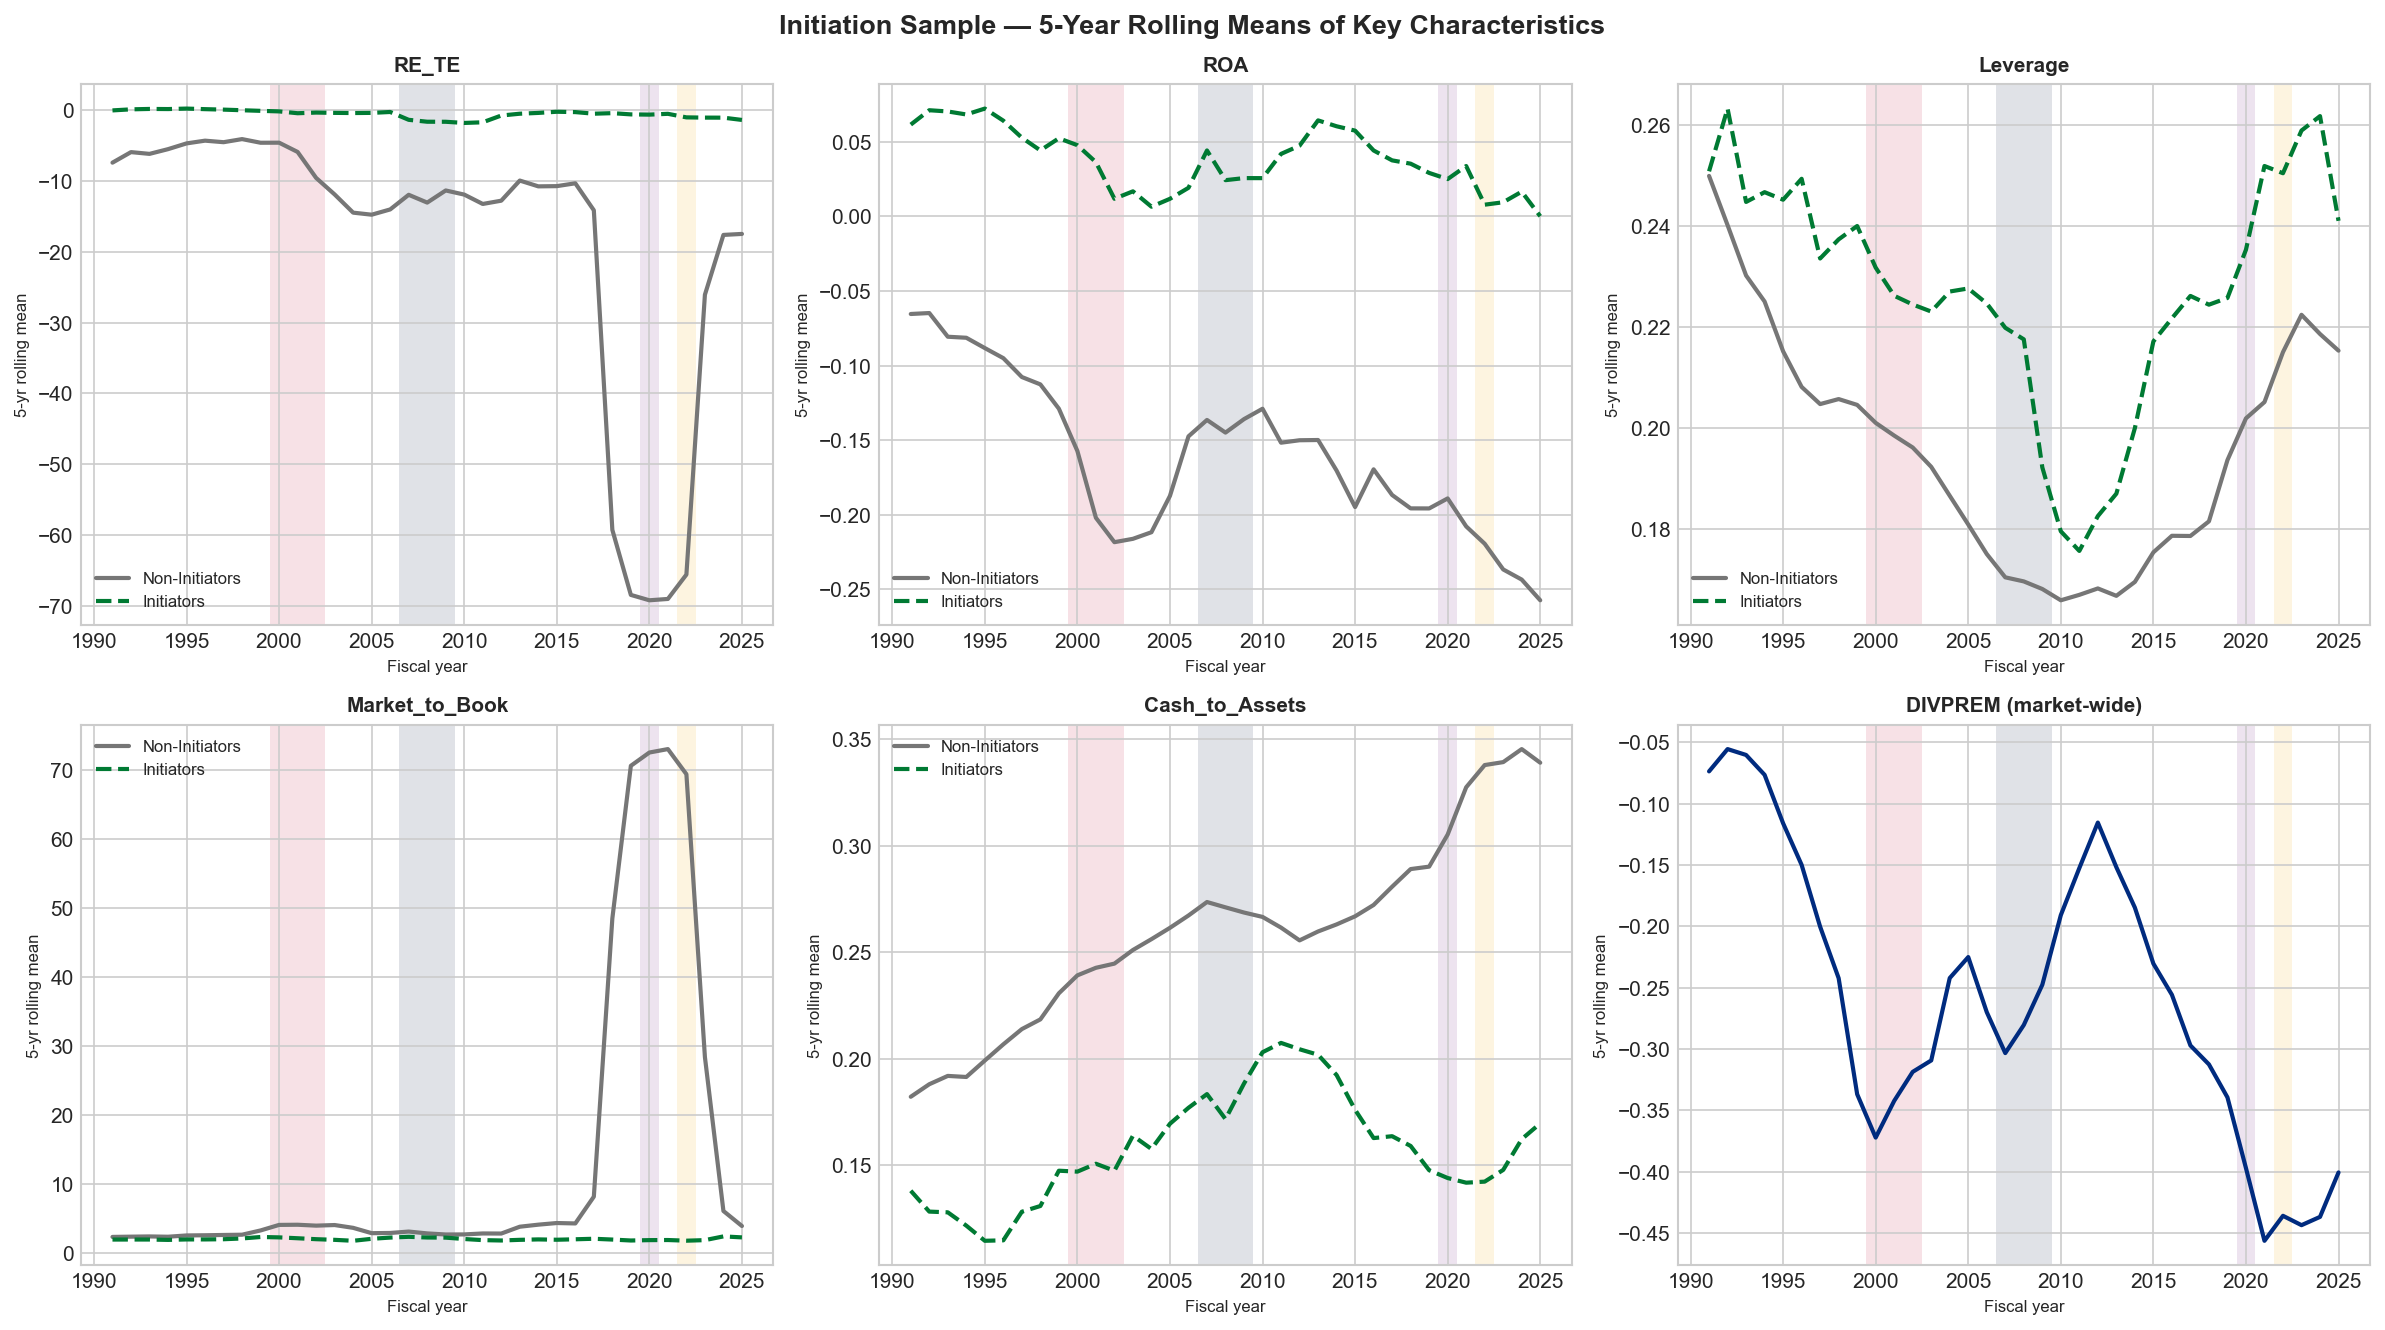

Saved: /Users/matyaslezatka/Documents/Thesis/Submission/results/figures/fig6_trends_initiation.png


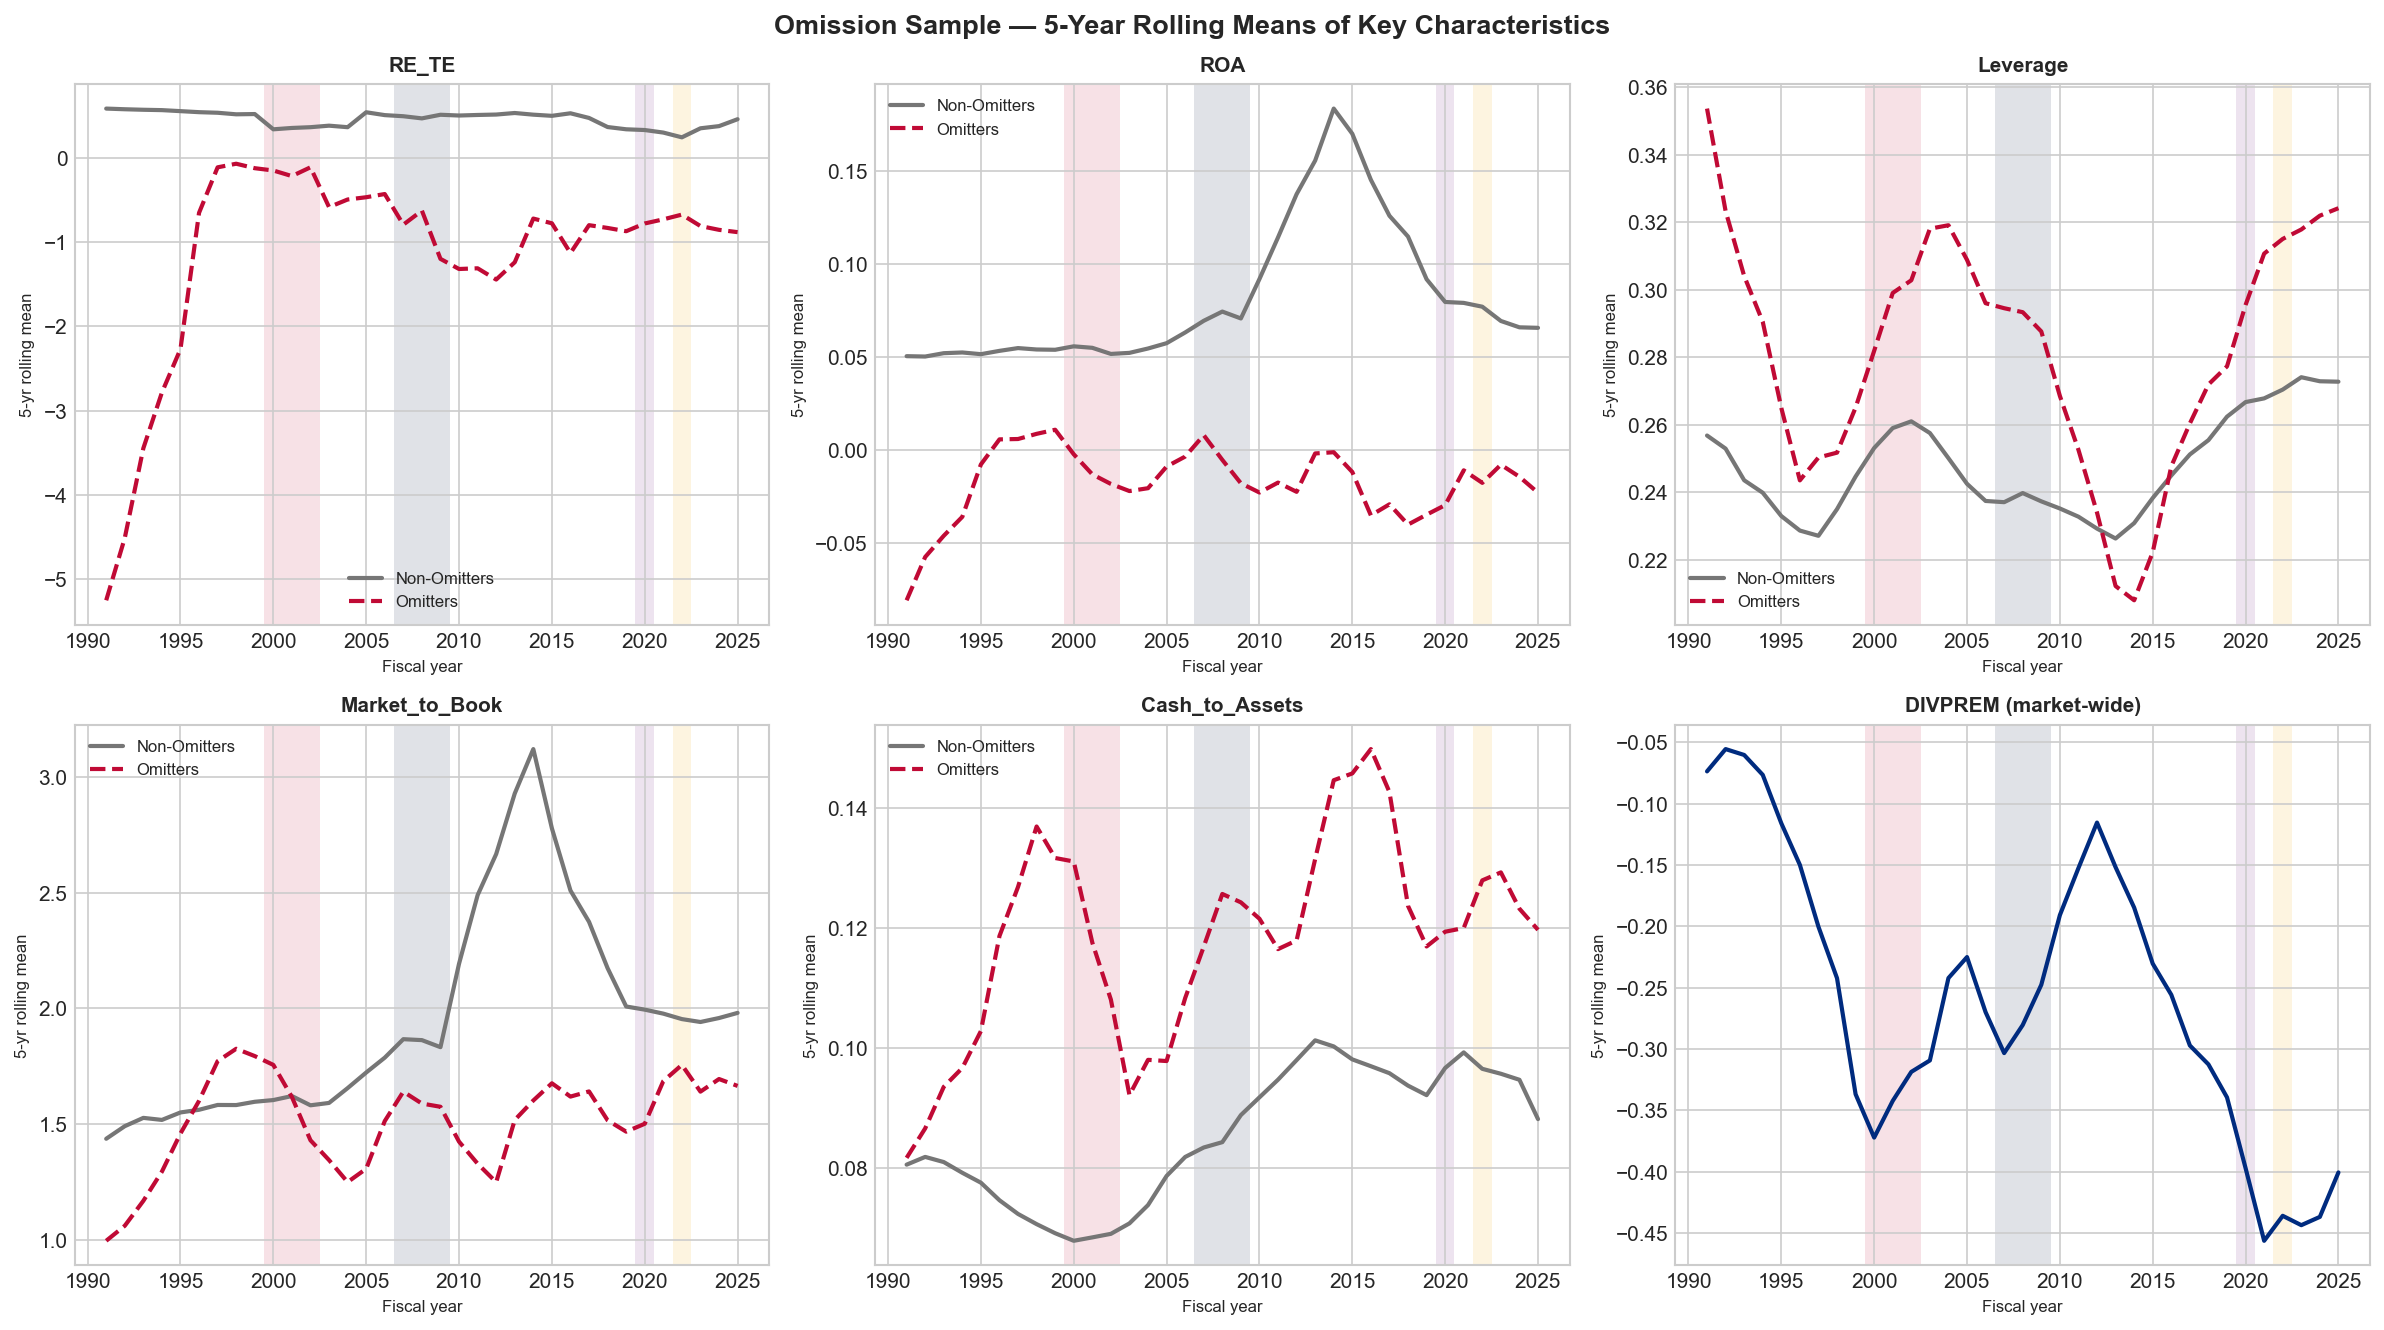

Saved: /Users/matyaslezatka/Documents/Thesis/Submission/results/figures/fig7_trends_omission.png


In [14]:
TREND_VARS = ['RE_TE', 'ROA', 'Leverage', 'Market_to_Book', 'Cash_to_Assets', 'DIVPREM']


def rolling_mean_by_group(df, target_col, var, window=5):
    """
    Compute annual mean for event and non-event groups, then apply a rolling mean.
    For market-wide vars, compute a single annual series.
    Returns a DataFrame indexed by FiscalYear.
    """
    if var not in df.columns:
        return None

    if var in MARKET_WIDE:
        annual = df.groupby('FiscalYear')[var].mean()
        out = pd.DataFrame({'Full sample': annual})
    else:
        ann_ne = df[df[target_col] == 0].groupby('FiscalYear')[var].mean()
        ann_ev = df[df[target_col] == 1].groupby('FiscalYear')[var].mean()
        out = pd.DataFrame({'Non-event': ann_ne, 'Event': ann_ev})

    out = out.rolling(window, min_periods=2).mean()
    return out


def plot_trends(df, target_col, event_color, non_event_color,
                event_label, non_event_label, fig_title, save_path):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), dpi=150)
    axes = axes.flatten()

    for idx, var in enumerate(TREND_VARS):
        ax = axes[idx]
        roll = rolling_mean_by_group(df, target_col, var)
        if roll is None:
            ax.set_visible(False)
            continue

        if var in MARKET_WIDE:
            ax.plot(roll.index, roll['Full sample'], color=UU_BLUE, lw=2)
            ax.set_title(f'{var} (market-wide)', fontweight='bold', fontsize=10)
        else:
            ax.plot(roll.index, roll['Non-event'], color=non_event_color,
                    lw=2, label=non_event_label)
            ax.plot(roll.index, roll['Event'], color=event_color,
                    lw=2, ls='--', label=event_label)
            ax.legend(fontsize=8)
            ax.set_title(var, fontweight='bold', fontsize=10)

        # Crisis shading
        ymin, ymax = ax.get_ylim()
        for cname, start, end, ccolor, calpha in CRISES:
            ax.axvspan(start - 0.5, end + 0.5, color=ccolor, alpha=calpha, lw=0, zorder=0)

        ax.set_xlabel('Fiscal year', fontsize=8)
        ax.set_ylabel('5-yr rolling mean', fontsize=8)

    fig.suptitle(fig_title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


plot_trends(
    init_desc, 'target_initiation', UU_GREEN, UU_GRAY,
    'Initiators', 'Non-Initiators',
    'Initiation Sample — 5-Year Rolling Means of Key Characteristics',
    FIGURES_DIR / 'fig6_trends_initiation.png',
)

plot_trends(
    omit_desc, 'target_omission', UU_RED, UU_GRAY,
    'Omitters', 'Non-Omitters',
    'Omission Sample — 5-Year Rolling Means of Key Characteristics',
    FIGURES_DIR / 'fig7_trends_omission.png',
)


## Section 11 — Missingness Summary

Percentage of missing values per variable and risk set. High-missingness variables (> 20%) are flagged because they may require special imputation treatment or warrant discussion as a data limitation.


Variables with >20.0% missing in at least one sample:


,Initiation (%),Omission (%)
Cash_ETR,23.4900,12.5300
Interest_Coverage,23.0400,28.9200
Current_Ratio,9.1100,40.5100
LCTAT,8.7200,39.2100


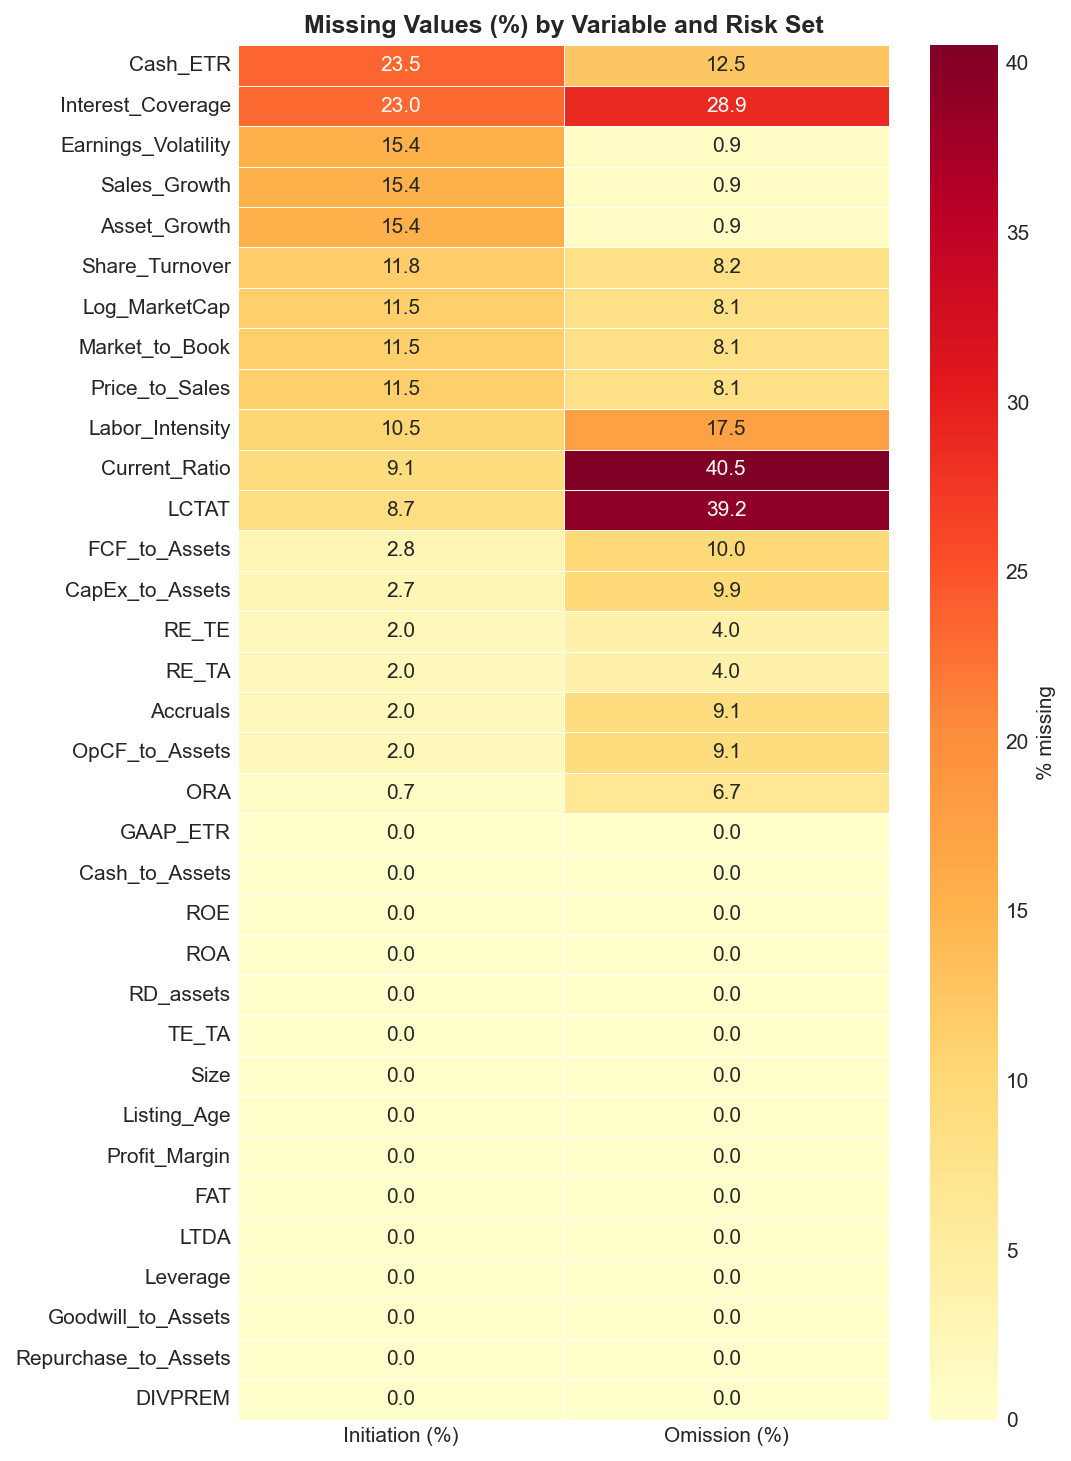

In [19]:
avail = [f for f in available_features if f in init_desc.columns and f in omit_desc.columns]

miss_df = pd.DataFrame({
    'Initiation (%)': init_desc[avail].isna().mean() * 100,
    'Omission (%)':   omit_desc[avail].isna().mean() * 100,
}).sort_values('Initiation (%)', ascending=False)

fig, ax = plt.subplots(figsize=(7, max(5, len(avail) * 0.35)), dpi=150)

sns.heatmap(
    miss_df,
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.4, cbar_kws={'label': '% missing'},
    ax=ax,
)
ax.set_title('Missing Values (%) by Variable and Risk Set', fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('')

threshold = 20.0
high_miss = miss_df[(miss_df['Initiation (%)'] > threshold) | (miss_df['Omission (%)'] > threshold)]
if high_miss.empty:
    print(f'No variables exceed {threshold}% missing in either sample.')
else:
    print(f'\nVariables with >{threshold}% missing in at least one sample:')
    display(high_miss.round(2))

## Section 12 — Headline Takeaways

Concise summary of key descriptive findings: event rates, top differentiating variables by Mann–Whitney rank, and the `DIVPREM` trend direction over the sample period.

In [16]:
# ── Top-3 differentiating variables per task (by MW test statistic magnitude) ─
# Use 1 - MW p-value as a proxy for discrimination strength (lower p = stronger)
def top_by_mw(raw_comp, k=3):
    sub = raw_comp[~raw_comp['Variable'].isin(MARKET_WIDE)].copy()
    return sub.nsmallest(k, 'MW p-value')['Variable'].tolist()

top3_init = top_by_mw(init_raw_comp)
top3_omit = top_by_mw(omit_raw_comp)

if 'DIVPREM' in init_desc.columns:
    divprem_annual = init_desc.groupby('FiscalYear')['DIVPREM'].mean()
    divprem_early  = divprem_annual.loc[divprem_annual.index <= 2002].mean()
    divprem_late   = divprem_annual.loc[divprem_annual.index >= 2010].mean()
    divprem_dir    = 'declined' if divprem_late < divprem_early else 'increased'
else:
    divprem_dir = 'not available'
    divprem_early = divprem_late = np.nan

print('=' * 70)
print('HEADLINE TAKEAWAYS')
print('=' * 70)
print()
print('EVENT RATES')
print(f'  - Initiation: {100 * init_desc["target_initiation"].mean():.2f}% of at-risk firm-years'
      f'  ({int(init_desc["target_initiation"].sum()):,} events out of {len(init_desc):,})')
print(f'  - Omission:   {100 * omit_desc["target_omission"].mean():.2f}% of prior-year payers'
      f'  ({int(omit_desc["target_omission"].sum()):,} events out of {len(omit_desc):,})')
print()
print('TOP 3 DIFFERENTIATING VARIABLES (by MW p-value)')
print(f'  - Initiation task: {top3_init}')
print(f'  - Omission task:   {top3_omit}')
print()
print('DIVPREM TREND (market-wide dividend premium)')
print(f'  - Mean DIVPREM 1990–2002 : {divprem_early:.4f}')
print(f'  - Mean DIVPREM 2010–2025 : {divprem_late:.4f}')
print(f'  - Direction over sample  : {divprem_dir}')
print()
print('=' * 70)


HEADLINE TAKEAWAYS

EVENT RATES
  - Initiation: 3.04% of at-risk firm-years  (2,858 events out of 94,127)
  - Omission:   4.03% of prior-year payers  (2,925 events out of 72,646)

TOP 3 DIFFERENTIATING VARIABLES (by MW p-value)
  - Initiation task: ['Profit_Margin', 'ROE', 'RE_TE']
  - Omission task:   ['Log_MarketCap', 'ROE', 'Profit_Margin']

DIVPREM TREND (market-wide dividend premium)
  - Mean DIVPREM 1990–2002 : -0.2124
  - Mean DIVPREM 2010–2025 : -0.3253
  - Direction over sample  : declined



## Section 13 — Thesis LaTeX Tables

Compact mean (SD) / median tables in the thesis LaTeX format — one for initiations (Table 5.1), one for omissions (Table 5.2). Variables are ordered by theory block with `DIVPREM` below a midrule separator.

In [17]:
DISPLAY_VARS = [
    ('RE_TE',                r'RE / Equity'),
    ('RE_TA',                r'RE / Assets'),
    ('TE_TA',                r'TE / Assets'),
    ('Size',                 r'Size'),
    ('Log_MarketCap',        r'Log market capitalization'),
    ('Sales_Growth',         r'Sales growth'),
    ('Asset_Growth',         r'Asset growth'),
    ('Listing_Age',          r'Listing age'),
    ('Market_to_Book',       r'Market-to-book'),
    ('CapEx_to_Assets',      r'CapEx / Assets'),
    ('RD_assets',            r'R\&D intensity'),
    ('Price_to_Sales',       r'Price / Sales'),
    ('ROA',                  r'ROA'),
    ('ROE',                  r'ROE'),
    ('OpCF_to_Assets',       r'Operating cash flow / Assets'),
    ('ORA',                  r'ORA'),
    ('Profit_Margin',        r'Profit margin'),
    ('Accruals',             r'Accruals'),
    ('Cash_to_Assets',       r'Cash / Assets'),
    ('FCF_to_Assets',        r'Free cash flow / Assets'),
    ('Repurchase_to_Assets', r'Repurchases / Assets'),
    ('Goodwill_to_Assets',   r'Goodwill / Assets'),
    ('Leverage',             r'Leverage'),
    ('LTDA',                 r'LT debt / Assets'),
    ('Current_Ratio',        r'Current ratio'),
    ('Earnings_Volatility',  r'Earnings volatility'),
    ('Interest_Coverage',    r'Interest coverage'),
    ('FAT',                  r'Financial asset tangibility'),
    ('LCTAT',                r'Current liabilities / Assets'),
    ('Labor_Intensity',      r'Labour intensity'),
    ('GAAP_ETR',             r'GAAP ETR'),
    ('Cash_ETR',             r'Cash ETR'),
    ('Share_Turnover',       r'Share turnover (millions)'),
]

# Market-wide variable appended below the midrule separator
MARKET_VARS = [
    ('DIVPREM', r'Dividend premium'),
]

assert len(DISPLAY_VARS) + len(MARKET_VARS) == 34, 'Final thesis table should cover all 34 variables.'


def _stats_row(display_name, ev, ne):
    """Format one data row: display_name | ev N | ev mean (SD) | ev median | ne N | ne mean (SD) | ne median."""
    return (
        f'{display_name:<40s}'
        f' & {len(ev):,}'
        f' & {ev.mean():.3f} ({ev.std():.3f})'
        f' & {ev.median():.3f}'
        f' & {len(ne):,}'
        f' & {ne.mean():.3f} ({ne.std():.3f})'
        f' & {ne.median():.3f} \\'
    )


def thesis_latex_table(df, target_col, event_label, non_event_label,
                       caption, label, save_path):
    """
    7-column thesis-format LaTeX table:
        Variable | Event N | Event mean (SD) | Event median
                 | Non-event N | Non-event mean (SD) | Non-event median

    Firm-level variables appear first, then a LaTeX midrule separator, then DIVPREM.
    DIVPREM is split by event status to show event-year clustering.
    """
    event_df     = df[df[target_col] == 1]
    non_event_df = df[df[target_col] == 0]

    # ── Main body rows ────────────────────────────────────────────────────
    rows = []
    for var, display_name in DISPLAY_VARS:
        if var not in df.columns:
            continue
        rows.append(_stats_row(
            display_name,
            event_df[var].dropna(),
            non_event_df[var].dropna(),
        ))

    # ── Market-wide rows (below separator) ────────────────────────────────
    market_rows = []
    for var, display_name in MARKET_VARS:
        if var not in df.columns:
            continue
        market_rows.append(_stats_row(
            display_name,
            event_df[var].dropna(),
            non_event_df[var].dropna(),
        ))

    body        = '\n'.join(rows)
    market_body = '\n'.join(market_rows)

    # ── LaTeX boilerplate ─────────────────────────────────────────────────
    lines = [
        r'\begin{table}[H]',
        r'\centering',
        r'\begin{minipage}{0.98\textwidth}',
        r'\centering',
        r'\scriptsize',
        r'\setlength{\tabcolsep}{3pt}',
        r'\renewcommand{\arraystretch}{1.08}',
        r'\rowcolors{2}{gray!5}{white}',
        r'\begin{tabularx}{\textwidth}{@{}>{\RaggedRight\arraybackslash}Xrrrrrr@{}}',
        r'\toprule',
        r'\rowcolor{gray!15}',
        (r'\textbf{Variable}'
         r' & \textbf{\shortstack[c]{' + event_label     + r'\\N}}'
         r' & \textbf{\shortstack[c]{' + event_label     + r'\\mean (SD)}}'
         r' & \textbf{\shortstack[c]{' + event_label     + r'\\median}}'
         r' & \textbf{\shortstack[c]{' + non_event_label + r'\\N}}'
         r' & \textbf{\shortstack[c]{' + non_event_label + r'\\mean (SD)}}'
         r' & \textbf{\shortstack[c]{' + non_event_label + r'\\median}} \\'),
        r'\midrule',
        body,
        # ── separator + market-wide block ─────────────────────────────────
        r'\midrule',
        r'\rowcolor{white}\multicolumn{7}{l}{\textit{Market-wide variable}} \\',
        market_body,
        r'\bottomrule',
        r'\end{tabularx}',
        '',
        r'{\captionsetup{skip=3pt}',
        r'\caption{' + caption + '}',
        r'\label{' + label + '}}',
        r'\end{minipage}',
        r'\end{table}',
    ]

    tex = '\n'.join(lines)
    with open(save_path, 'w') as fh:
        fh.write(tex)
    print(f'Saved: {save_path}')
    return tex


init_tex = thesis_latex_table(
    init_desc, 'target_initiation',
    event_label     = 'Initiator',
    non_event_label = 'Non-initiator',
    caption = ('Descriptive statistics for initiation and non-initiation firm-years. '
               'Columns report N, mean (standard deviation), and median. '
               'Dividend premium is reported below the separator as the market-wide variable.'),
    label     = 'tab:desc_initiation',
    save_path = TABLES_DIR / 'tab_desc_initiation.tex',
)

omit_tex = thesis_latex_table(
    omit_desc, 'target_omission',
    event_label     = 'Omitter',
    non_event_label = 'Non-omitter',
    caption = ('Descriptive statistics for omission and non-omission firm-years. '
               'Columns report N, mean (standard deviation), and median. '
               'Dividend premium is reported below the separator as the market-wide variable.'),
    label     = 'tab:desc_omission',
    save_path = TABLES_DIR / 'tab_desc_omission.tex',
)

for label, tex in [('Initiation', init_tex), ('Omission', omit_tex)]:
    print(f'\n── {label}: last 6 data lines (including market vars) ──')
    data_lines = [l for l in tex.split('\n')
                  if '&' in l and r'\textbf' not in l and r'\multicolumn' not in l]
    print('\n'.join(data_lines[-6:]))


Saved: /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/tab_desc_initiation.tex
Saved: /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/tab_desc_omission.tex

── Initiation: last 6 data lines (including market vars) ──
Current liabilities / Assets             & 2,061 & 0.244 (0.173) & 0.199 & 83,855 & 0.264 (0.186) & 0.216 \
Labour intensity                         & 2,207 & 0.082 (0.373) & 0.027 & 82,065 & 0.125 (2.132) & 0.036 \
GAAP ETR                                 & 2,858 & 0.261 (1.446) & 0.312 & 91,237 & 0.099 (9.053) & 0.050 \
Cash ETR                                 & 2,391 & 0.270 (3.986) & 0.166 & 69,625 & 0.119 (7.989) & 0.028 \
Share turnover (millions)                & 2,299 & 84934330.275 (3379654798.444) & 843976.500 & 80,753 & 5361144.390 (777249269.101) & 1019636.491 \
Dividend premium                         & 2,858 & -0.246 (0.137) & -0.259 & 91,269 & -0.259 (0.150) & -0.259 \

── Omission: last 6 data lines (including market vars) ──